## Can quantitative macro-financial regime signals improve the dynamic allocation of equity factors out of sample after transaction costs?

### Data Overview

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
import re
from io import StringIO


In [3]:
# ============================================================
# LOAD YOUR COMBINED RESEARCH DATASET
# ============================================================
DATA_DIR = Path(".")

research_data = pd.read_csv(
    DATA_DIR / "research_data.csv",
    index_col="Date",
    parse_dates=["Date"]
)

# Make sure dates are sorted
research_data = research_data.sort_index()

print("Dataset loaded successfully!")
print("Shape:", research_data.shape)
print("Date range:", research_data.index.min(), "to", research_data.index.max())

print("\nColumns:")
print(research_data.columns.tolist())

print("\nFirst 5 rows:")
print(research_data.head())


Dataset loaded successfully!
Shape: (1293, 16)
Date range: 1919-01-31 00:00:00 to 2026-09-30 00:00:00

Columns:
['VIX', 'CPI', 'Inflation', 'Credit_Spread', 'Term_Spread', 'Unemployment', 'Treasury_2Y', 'Industrial_Production', 'IP_Growth', 'MOM', 'MKT_RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF']

First 5 rows:
            VIX  CPI  Inflation  Credit_Spread  Term_Spread  Unemployment  \
Date                                                                        
1919-01-31  NaN  NaN        NaN            NaN          NaN           NaN   
1919-02-28  NaN  NaN        NaN            NaN          NaN           NaN   
1919-03-31  NaN  NaN        NaN            NaN          NaN           NaN   
1919-04-30  NaN  NaN        NaN            NaN          NaN           NaN   
1919-05-31  NaN  NaN        NaN            NaN          NaN           NaN   

            Treasury_2Y  Industrial_Production  IP_Growth  MOM  MKT_RF  SMB  \
Date                                                                      

In [4]:
# ============================================================
# CHECK REMAINING MISSING VALUES
# ============================================================

missing_rows = research_data[
    research_data.isna().any(axis=1)
]

print("Rows containing missing values:")
print(missing_rows)

print("\nMissing values by variable:")
print(research_data.isna().sum())


Rows containing missing values:
                  VIX    CPI  Inflation  Credit_Spread  Term_Spread  \
Date                                                                  
1919-01-31        NaN    NaN        NaN            NaN          NaN   
1919-02-28        NaN    NaN        NaN            NaN          NaN   
1919-03-31        NaN    NaN        NaN            NaN          NaN   
1919-04-30        NaN    NaN        NaN            NaN          NaN   
1919-05-31        NaN    NaN        NaN            NaN          NaN   
...               ...    ...        ...            ...          ...   
1989-11-30        NaN  125.9   0.398724       1.938095     0.078571   
1989-12-31        NaN  126.3   0.317712       1.982500     0.059000   
2025-10-31  18.086522    NaN        NaN       1.673182     0.540455   
2026-08-31  15.229524    NaN        NaN       1.631905     0.468095   
2026-09-30  15.286667    NaN        NaN       1.576667     0.410000   

            Unemployment  Treasury_2Y  Indus

In [5]:
# ============================================================
# STEP 1. CREATE COMMON RESEARCH SAMPLE
# ============================================================

research_sample = research_data.loc[
    "1990-01-31":"2026-07-31"
].copy()

print("Research sample shape:")
print(research_sample.shape)

print("\nDate range:")
print(research_sample.index.min())
print(research_sample.index.max())

print("\nMissing values:")
print(research_sample.isna().sum())


Research sample shape:
(439, 16)

Date range:
1990-01-31 00:00:00
2026-07-31 00:00:00

Missing values:
VIX                      0
CPI                      1
Inflation                1
Credit_Spread            0
Term_Spread              0
Unemployment             1
Treasury_2Y              0
Industrial_Production    0
IP_Growth                0
MOM                      0
MKT_RF                   0
SMB                      0
HML                      0
RMW                      0
CMA                      0
RF                       0
dtype: int64


In [6]:
# ============================================================
# FINAL MODEL DATA CONSTRUCTION
# ============================================================

# Start directly from research_sample
# Do NOT drop missing rows yet

model_data = research_sample[
    [
        "MKT_RF",
        "SMB",
        "HML",
        "RMW",
        "CMA",
        "MOM",
        "RF",

        "VIX",
        "Credit_Spread",
        "Term_Spread",
        "Treasury_2Y",
        "Inflation",
        "Unemployment",
        "IP_Growth"
    ]
].copy()


# ============================================================
# 1. CREATE LAGGED MACRO VARIABLES
# ============================================================

model_data["Inflation_lag1"] = (
    model_data["Inflation"].shift(1)
)

model_data["Unemployment_lag1"] = (
    model_data["Unemployment"].shift(1)
)

model_data["IP_Growth_lag1"] = (
    model_data["IP_Growth"].shift(1)
)


# ============================================================
# 2. CREATE NEXT-MONTH FACTOR TARGETS
# ============================================================

factor_columns = [
    "MKT_RF",
    "SMB",
    "HML",
    "RMW",
    "CMA",
    "MOM"
]

for factor in factor_columns:

    model_data[f"{factor}_next"] = (
        model_data[factor].shift(-1)
    )


# ============================================================
# 3. DEFINE PREDICTOR VARIABLES
# ============================================================

predictor_columns = [
    "VIX",
    "Credit_Spread",
    "Term_Spread",
    "Treasury_2Y",
    "Inflation_lag1",
    "Unemployment_lag1",
    "IP_Growth_lag1"
]


# ============================================================
# 4. DEFINE TARGET VARIABLES
# ============================================================

target_columns = [
    f"{factor}_next"
    for factor in factor_columns
]


# ============================================================
# 5. DROP MISSING VALUES ONLY NOW
# ============================================================

required_columns = (
    predictor_columns
    + target_columns
)

model_data = model_data.dropna(
    subset=required_columns
).copy()


# ============================================================
# 6. FINAL CHECK
# ============================================================

print("Final model dataset shape:")
print(model_data.shape)

print("\nDate range:")
print(
    model_data.index.min(),
    "to",
    model_data.index.max()
)

print("\nMissing values:")
print(
    model_data[
        required_columns
    ].isna().sum()
)

print("\nDuplicate dates:")
print(
    model_data.index.duplicated().sum()
)

print("\nDates sorted:")
print(
    model_data.index.is_monotonic_increasing
)


Final model dataset shape:
(436, 23)

Date range:
1990-02-28 00:00:00 to 2026-06-30 00:00:00

Missing values:
VIX                  0
Credit_Spread        0
Term_Spread          0
Treasury_2Y          0
Inflation_lag1       0
Unemployment_lag1    0
IP_Growth_lag1       0
MKT_RF_next          0
SMB_next             0
HML_next             0
RMW_next             0
CMA_next             0
MOM_next             0
dtype: int64

Duplicate dates:
0

Dates sorted:
True


In [7]:
summary = model_data.describe().T
summary["missing"] = model_data.isna().sum()

print(summary.round(3))

                   count    mean    std     min     25%     50%     75%  \
MKT_RF             436.0   0.770  4.387 -17.200  -1.915   1.255   3.430   
SMB                436.0   0.083  3.055 -15.530  -1.830  -0.020   1.840   
HML                436.0   0.154  3.230 -13.830  -1.680  -0.090   1.762   
RMW                436.0   0.300  2.643 -18.930  -0.998   0.325   1.455   
CMA                436.0   0.161  2.186  -7.060  -1.145  -0.060   1.388   
MOM                436.0   0.500  4.643 -34.360  -1.318   0.610   2.932   
RF                 436.0   0.223  0.186   0.000   0.010   0.210   0.392   
VIX                436.0  19.449  7.389  10.125  14.114  17.673  22.903   
Credit_Spread      436.0   2.286  0.710   1.290   1.740   2.159   2.688   
Term_Spread        436.0   1.006  0.911  -0.929   0.250   0.843   1.764   
Treasury_2Y        436.0   3.237  2.247   0.115   0.954   3.404   4.970   
Inflation          435.0   0.220  0.271  -1.771   0.100   0.217   0.339   
Unemployment       435.0 

In [8]:
correlation = model_data[
    predictor_columns
].corr()

print(correlation.round(3))


                     VIX  Credit_Spread  Term_Spread  Treasury_2Y  \
VIX                1.000          0.633        0.100       -0.116   
Credit_Spread      0.633          1.000        0.501       -0.588   
Term_Spread        0.100          0.501        1.000       -0.536   
Treasury_2Y       -0.116         -0.588       -0.536        1.000   
Inflation_lag1    -0.153         -0.321       -0.117        0.159   
Unemployment_lag1  0.135          0.416        0.718       -0.391   
IP_Growth_lag1    -0.187         -0.271       -0.008        0.090   

                   Inflation_lag1  Unemployment_lag1  IP_Growth_lag1  
VIX                        -0.153              0.135          -0.187  
Credit_Spread              -0.321              0.416          -0.271  
Term_Spread                -0.117              0.718          -0.008  
Treasury_2Y                 0.159             -0.391           0.090  
Inflation_lag1              1.000             -0.144           0.205  
Unemployment_lag1    

In [9]:
# ============================================================
# CORRECT VIF CHECK — INCLUDE CONSTANT
# ============================================================

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import (
    variance_inflation_factor
)

X_vif = model_data[predictor_columns].copy()

# Add intercept
X_vif_const = sm.add_constant(X_vif)

vif = pd.DataFrame({
    "Variable": X_vif_const.columns,
    "VIF": [
        variance_inflation_factor(
            X_vif_const.values, i
        )
        for i in range(X_vif_const.shape[1])
    ]
})

# Remove constant from displayed results
vif = vif[vif["Variable"] != "const"]

print(
    vif.sort_values(
        "VIF",
        ascending=False
    ).round(3)
)


            Variable    VIF
2      Credit_Spread  3.845
3        Term_Spread  2.653
1                VIX  2.125
6  Unemployment_lag1  2.097
4        Treasury_2Y  1.962
5     Inflation_lag1  1.151
7     IP_Growth_lag1  1.125


In [10]:
# ============================================================
# STATIONARITY CHECK — ADF TEST
# ============================================================

from statsmodels.tsa.stattools import adfuller
import pandas as pd

adf_results = []

for col in predictor_columns:
    series = model_data[col].dropna()

    result = adfuller(series, autolag="AIC")

    adf_results.append({
        "Variable": col,
        "ADF_Statistic": result[0],
        "p_value": result[1],
        "Stationary_5pct": result[1] < 0.05
    })

adf_results = pd.DataFrame(adf_results)

print(adf_results.round(4))


            Variable  ADF_Statistic  p_value  Stationary_5pct
0                VIX        -5.2455   0.0000             True
1      Credit_Spread        -3.8641   0.0023             True
2        Term_Spread        -3.4082   0.0107             True
3        Treasury_2Y        -2.7114   0.0721            False
4     Inflation_lag1        -3.9590   0.0016             True
5  Unemployment_lag1        -2.7061   0.0730            False
6     IP_Growth_lag1       -15.2664   0.0000             True


In [11]:
# ============================================================
# ADF TEST — NEXT-MONTH FACTOR TARGETS
# ============================================================

target_adf = []

for col in target_columns:
    series = model_data[col].dropna()

    result = adfuller(series, autolag="AIC")

    target_adf.append({
        "Target": col,
        "ADF_Statistic": result[0],
        "p_value": result[1],
        "Stationary_5pct": result[1] < 0.05
    })

target_adf = pd.DataFrame(target_adf)

print(target_adf.round(4))


        Target  ADF_Statistic  p_value  Stationary_5pct
0  MKT_RF_next       -20.4809      0.0             True
1     SMB_next       -21.5538      0.0             True
2     HML_next       -17.7771      0.0             True
3     RMW_next        -5.9356      0.0             True
4     CMA_next       -18.5774      0.0             True
5     MOM_next       -19.9045      0.0             True


In [12]:
# ============================================================
# FINAL PRE-MODELING CHECK
# ============================================================

print("Shape:", model_data.shape)
print("Start:", model_data.index.min())
print("End:", model_data.index.max())

print("\nDuplicate dates:")
print(model_data.index.duplicated().sum())

print("\nDates sorted:")
print(model_data.index.is_monotonic_increasing)

print("\nMissing predictors:")
print(model_data[predictor_columns].isna().sum())

print("\nMissing targets:")
print(model_data[target_columns].isna().sum())


Shape: (436, 23)
Start: 1990-02-28 00:00:00
End: 2026-06-30 00:00:00

Duplicate dates:
0

Dates sorted:
True

Missing predictors:
VIX                  0
Credit_Spread        0
Term_Spread          0
Treasury_2Y          0
Inflation_lag1       0
Unemployment_lag1    0
IP_Growth_lag1       0
dtype: int64

Missing targets:
MKT_RF_next    0
SMB_next       0
HML_next       0
RMW_next       0
CMA_next       0
MOM_next       0
dtype: int64


In [13]:
# ============================================================
# KPSS TEST — CONFIRM BORDERLINE ADF RESULTS
# ============================================================

from statsmodels.tsa.stattools import kpss
import pandas as pd

kpss_results = []

for col in predictor_columns:
    
    series = model_data[col].dropna()

    statistic, p_value, lags, critical_values = kpss(
        series,
        regression="c",
        nlags="auto"
    )

    kpss_results.append({
        "Variable": col,
        "KPSS_Statistic": statistic,
        "p_value": p_value,
        "Stationary_5pct": p_value > 0.05
    })

kpss_results = pd.DataFrame(kpss_results)

print(kpss_results.round(4))


            Variable  KPSS_Statistic  p_value  Stationary_5pct
0                VIX          0.1170   0.1000             True
1      Credit_Spread          0.4295   0.0645             True
2        Term_Spread          0.3352   0.1000             True
3        Treasury_2Y          1.7794   0.0100            False
4     Inflation_lag1          0.2409   0.1000             True
5  Unemployment_lag1          0.3201   0.1000             True
6     IP_Growth_lag1          0.3625   0.0933             True


/tmp/ipykernel_108/5000228.py:14: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  statistic, p_value, lags, critical_values = kpss(
/tmp/ipykernel_108/5000228.py:14: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  statistic, p_value, lags, critical_values = kpss(
/tmp/ipykernel_108/5000228.py:14: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  statistic, p_value, lags, critical_values = kpss(
/tmp/ipykernel_108/5000228.py:14: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  statistic, p_value, lags, critical_val

In [14]:
# ============================================================
# TRANSFORM TREASURY 2Y AND UPDATE FINAL PREDICTORS
# ============================================================

# 1. Create monthly change in Treasury 2Y
model_data["Treasury_2Y_change"] = (
    model_data["Treasury_2Y"].diff()
)

# 2. Remove the first observation created as NaN by differencing
model_data = model_data.dropna(
    subset=["Treasury_2Y_change"]
).copy()

# 3. REDEFINE the final predictor list
predictor_columns = [
    "VIX",
    "Credit_Spread",
    "Term_Spread",
    "Treasury_2Y_change",
    "Inflation_lag1",
    "Unemployment_lag1",
    "IP_Growth_lag1"
]

# 4. Check
print("Final predictor variables:")
print(predictor_columns)

print("\nFinal model_data shape:")
print(model_data.shape)


Final predictor variables:
['VIX', 'Credit_Spread', 'Term_Spread', 'Treasury_2Y_change', 'Inflation_lag1', 'Unemployment_lag1', 'IP_Growth_lag1']

Final model_data shape:
(435, 24)


In [15]:
# ============================================================
# VERIFY TREASURY CHANGE IS STATIONARY
# ============================================================

from statsmodels.tsa.stattools import adfuller

series = model_data["Treasury_2Y_change"].dropna()

result = adfuller(
    series,
    autolag="AIC"
)

print("Treasury_2Y_change")
print("ADF Statistic:", round(result[0], 4))
print("p-value:", round(result[1], 4))
print("Stationary at 5%:", result[1] < 0.05)


Treasury_2Y_change
ADF Statistic: -4.7878
p-value: 0.0001
Stationary at 5%: True


In [16]:
# ============================================================
# FINAL CORRELATION + VIF CHECK AFTER TREASURY TRANSFORMATION
# ============================================================

import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Correlation
final_corr = model_data[predictor_columns].corr()

print("FINAL PREDICTOR CORRELATION MATRIX:")
print(final_corr.round(3))


# VIF
X_vif = model_data[predictor_columns].copy()
X_vif_const = sm.add_constant(X_vif)

final_vif = pd.DataFrame({
    "Variable": X_vif_const.columns,
    "VIF": [
        variance_inflation_factor(X_vif_const.values, i)
        for i in range(X_vif_const.shape[1])
    ]
})

final_vif = final_vif[
    final_vif["Variable"] != "const"
].sort_values("VIF", ascending=False)

print("\nFINAL VIF:")
print(final_vif.round(3))


FINAL PREDICTOR CORRELATION MATRIX:
                      VIX  Credit_Spread  Term_Spread  Treasury_2Y_change  \
VIX                 1.000          0.634        0.102              -0.245   
Credit_Spread       0.634          1.000        0.500              -0.193   
Term_Spread         0.102          0.500        1.000              -0.058   
Treasury_2Y_change -0.245         -0.193       -0.058               1.000   
Inflation_lag1     -0.158         -0.319       -0.112               0.154   
Unemployment_lag1   0.135          0.416        0.719              -0.044   
IP_Growth_lag1     -0.186         -0.273       -0.009               0.090   

                    Inflation_lag1  Unemployment_lag1  IP_Growth_lag1  
VIX                         -0.158              0.135          -0.186  
Credit_Spread               -0.319              0.416          -0.273  
Term_Spread                 -0.112              0.719          -0.009  
Treasury_2Y_change           0.154             -0.044      

### Modeling

In [17]:
# ============================================================
# MODELING STEP 1 — FINAL VARIABLES
# ============================================================

predictor_columns = [
    "VIX",
    "Credit_Spread",
    "Term_Spread",
    "Treasury_2Y_change",
    "Inflation_lag1",
    "Unemployment_lag1",
    "IP_Growth_lag1"
]

target_columns = [
    "MKT_RF_next",
    "SMB_next",
    "HML_next",
    "RMW_next",
    "CMA_next",
    "MOM_next"
]

factor_names = [
    "MKT_RF",
    "SMB",
    "HML",
    "RMW",
    "CMA",
    "MOM"
]

# Ensure chronological order
model_data = model_data.sort_index()

print("Observations:", len(model_data))
print("Predictors:", predictor_columns)
print("Targets:", target_columns)


Observations: 435
Predictors: ['VIX', 'Credit_Spread', 'Term_Spread', 'Treasury_2Y_change', 'Inflation_lag1', 'Unemployment_lag1', 'IP_Growth_lag1']
Targets: ['MKT_RF_next', 'SMB_next', 'HML_next', 'RMW_next', 'CMA_next', 'MOM_next']


In [18]:
# ============================================================
# MODELING STEP 2 — CHRONOLOGICAL SPLIT
# ============================================================

n = len(model_data)

train_end = int(n * 0.60)
val_end = int(n * 0.80)

train_data = model_data.iloc[:train_end].copy()
validation_data = model_data.iloc[train_end:val_end].copy()
test_data = model_data.iloc[val_end:].copy()

print("TRAIN:")
print(
    len(train_data),
    train_data.index.min(),
    train_data.index.max()
)

print("\nVALIDATION:")
print(
    len(validation_data),
    validation_data.index.min(),
    validation_data.index.max()
)

print("\nTEST:")
print(
    len(test_data),
    test_data.index.min(),
    test_data.index.max()
)


TRAIN:
261 1990-03-31 00:00:00 2011-11-30 00:00:00

VALIDATION:
87 2011-12-31 00:00:00 2019-02-28 00:00:00

TEST:
87 2019-03-31 00:00:00 2026-06-30 00:00:00


In [19]:
# ============================================================
# MODELING STEP 3 — HISTORICAL MEAN BENCHMARK (Model 0)
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error

benchmark_results = []

for target in target_columns:

    # Training historical mean
    historical_mean = train_data[target].mean()

    y_val = validation_data[target]

    # Same forecast for each validation month
    pred = np.repeat(
        historical_mean,
        len(y_val)
    )

    rmse = np.sqrt(
        mean_squared_error(y_val, pred)
    )

    mae = mean_absolute_error(
        y_val,
        pred
    )

    benchmark_results.append({
        "Factor": target,
        "Historical_Mean": historical_mean,
        "Validation_RMSE": rmse,
        "Validation_MAE": mae
    })

benchmark_results = pd.DataFrame(
    benchmark_results
)

print(
    benchmark_results.round(4)
)


        Factor  Historical_Mean  Validation_RMSE  Validation_MAE
0  MKT_RF_next           0.5189           3.2844          2.5140
1     SMB_next           0.2158           2.3581          1.8796
2     HML_next           0.2664           2.2338          1.7294
3     RMW_next           0.4498           1.5321          1.2101
4     CMA_next           0.2926           1.4739          1.1763
5     MOM_next           0.6207           3.1655          2.3469


In [20]:
# ============================================================
# MODELING STEP 4 — Main econometric model: predictive regression (OLS) + Newey-West/HAC
# ============================================================

import statsmodels.api as sm

hac_results = []

for target in target_columns:

    X = model_data[predictor_columns]
    X = sm.add_constant(X)

    y = model_data[target]

    model = sm.OLS(
        y,
        X
    ).fit(
        cov_type="HAC",
        cov_kwds={
            "maxlags": 3
        }
    )

    for variable in predictor_columns:

        hac_results.append({
            "Factor": target,
            "Variable": variable,
            "Coefficient": model.params[variable],
            "HAC_t": model.tvalues[variable],
            "HAC_p": model.pvalues[variable],
            "R_squared": model.rsquared,
            "Adj_R_squared": model.rsquared_adj
        })

hac_results = pd.DataFrame(
    hac_results
)

print(
    hac_results.round(4)
)


         Factor            Variable  Coefficient   HAC_t   HAC_p  R_squared  \
0   MKT_RF_next                 VIX       0.0880  1.8260  0.0679     0.0301   
1   MKT_RF_next       Credit_Spread      -0.7309 -1.3234  0.1857     0.0301   
2   MKT_RF_next         Term_Spread      -0.3415 -1.0880  0.2766     0.0301   
3   MKT_RF_next  Treasury_2Y_change       0.4019  0.4285  0.6683     0.0301   
4   MKT_RF_next      Inflation_lag1      -0.2896 -0.2630  0.7925     0.0301   
5   MKT_RF_next   Unemployment_lag1       0.4422  2.9607  0.0031     0.0301   
6   MKT_RF_next      IP_Growth_lag1       0.2329  1.3299  0.1836     0.0301   
7      SMB_next                 VIX       0.0014  0.0505  0.9597     0.0216   
8      SMB_next       Credit_Spread       0.4225  1.4592  0.1445     0.0216   
9      SMB_next         Term_Spread       0.2137  0.9482  0.3430     0.0216   
10     SMB_next  Treasury_2Y_change       0.6754  0.8986  0.3688     0.0216   
11     SMB_next      Inflation_lag1      -0.2601 -0.



Which macroeconomic variables significantly predict which factor returns?



In [21]:
# ============================================================
# MODELING STEP 5 — PCA ROBUSTNESS
# ============================================================

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X_train = train_data[predictor_columns]

scaler_pca = StandardScaler()

X_train_scaled = scaler_pca.fit_transform(
    X_train
)

pca = PCA()

X_train_pca = pca.fit_transform(
    X_train_scaled
)

explained = pd.DataFrame({
    "PC": [
        f"PC{i+1}"
        for i in range(
            len(pca.explained_variance_ratio_)
        )
    ],
    "Explained_Variance": (
        pca.explained_variance_ratio_
    ),
    "Cumulative_Variance": (
        np.cumsum(
            pca.explained_variance_ratio_
        )
    )
})

print(
    explained.round(4)
)


    PC  Explained_Variance  Cumulative_Variance
0  PC1              0.3828               0.3828
1  PC2              0.2214               0.6042
2  PC3              0.1353               0.7395
3  PC4              0.1237               0.8632
4  PC5              0.0898               0.9530
5  PC6              0.0298               0.9828
6  PC7              0.0172               1.0000


### Redesign the Macroeconomic Regime Classification

The previous three groups:`Expansion`, `Normal`, `Stress`.

1. **M1 — Growth × Inflation:** classify months using industrial-production growth and inflation.
2. **M2 — Growth Index × Pressure Index:** combine the seven macro predictors into two economic composite indices.
3. **M3 — PCA + K-means:** use unsupervised dimension reduction and clustering to identify four data-driven macro states.

**M1 prefered** 

In [22]:
# ============================================================
# SUGGESTION #1 — COMMON SETUP
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Use the modeling dataset already constructed earlier in this notebook.
regime_base = model_data.copy()

# Training sample for estimating thresholds/scalers.
# If train_data already exists, use it to reduce look-ahead bias.
regime_train = train_data.copy() if "train_data" in globals() else regime_base.copy()

macro7 = [
    "VIX",
    "Credit_Spread",
    "Term_Spread",
    "Treasury_2Y_change",
    "Inflation_lag1",
    "Unemployment_lag1",
    "IP_Growth_lag1"
]

factor_next = [
    "MKT_RF_next", "SMB_next", "HML_next",
    "RMW_next", "CMA_next", "MOM_next"
]

print("Regime sample:", regime_base.shape)
print("Training sample used for thresholds/scalers:", regime_train.shape)
print("Macro variables:", macro7)


Regime sample: (435, 24)
Training sample used for thresholds/scalers: (261, 24)
Macro variables: ['VIX', 'Credit_Spread', 'Term_Spread', 'Treasury_2Y_change', 'Inflation_lag1', 'Unemployment_lag1', 'IP_Growth_lag1']


### M1 — Growth × Inflation Classification

- **Growth:** lagged industrial-production growth (`IP_Growth_lag1`)
- **Inflation:** lagged inflation (`Inflation_lag1`)

To avoid imposing arbitrary numerical cutoffs, the training-sample medians define `High` versus `Low`.

| Growth | Inflation | Regime |
|---|---|---|
| High | Low | Goldilocks |
| High | High | Inflationary Growth |
| Low | High | Stagflation |
| Low | Low | Contraction / Disinflation |

In [23]:
# ============================================================
# M1 — GROWTH × INFLATION
# ============================================================
m1 = regime_base.copy()

growth_cut = regime_train["IP_Growth_lag1"].median()
infl_cut = regime_train["Inflation_lag1"].median()

def classify_m1(row):
    high_growth = row["IP_Growth_lag1"] > growth_cut
    high_infl = row["Inflation_lag1"] > infl_cut

    if high_growth and not high_infl:
        return "Expansion"

    elif high_growth and high_infl:
        return "Overheating"

    elif (not high_growth) and high_infl:
        return "Stagflation"

    else:
        return "Slowdown"

m1["Regime_M1"] = m1.apply(classify_m1, axis=1)

print(f"Growth threshold (training median): {growth_cut:.4f}")
print(f"Inflation threshold (training median): {infl_cut:.4f}")
print("\nM1 regime counts:")
print(m1["Regime_M1"].value_counts())

m1_summary = m1.groupby("Regime_M1")[factor_next].mean().round(3)
print("\nAverage next-month factor returns:")
display(m1_summary)

Growth threshold (training median): 0.2483
Inflation threshold (training median): 0.2169

M1 regime counts:
Regime_M1
Stagflation    129
Slowdown       115
Expansion      102
Overheating     89
Name: count, dtype: int64

Average next-month factor returns:


,MKT_RF_next,SMB_next,HML_next,RMW_next,CMA_next,MOM_next
Regime_M1,,,,,,
Expansion,1.211,0.122,-0.120,-0.002,0.008,0.847
Overheating,0.132,-0.445,0.830,0.666,0.635,0.791
Slowdown,0.614,0.255,-0.371,0.015,0.240,0.334
Stagflation,0.981,0.255,0.418,0.622,-0.080,0.079


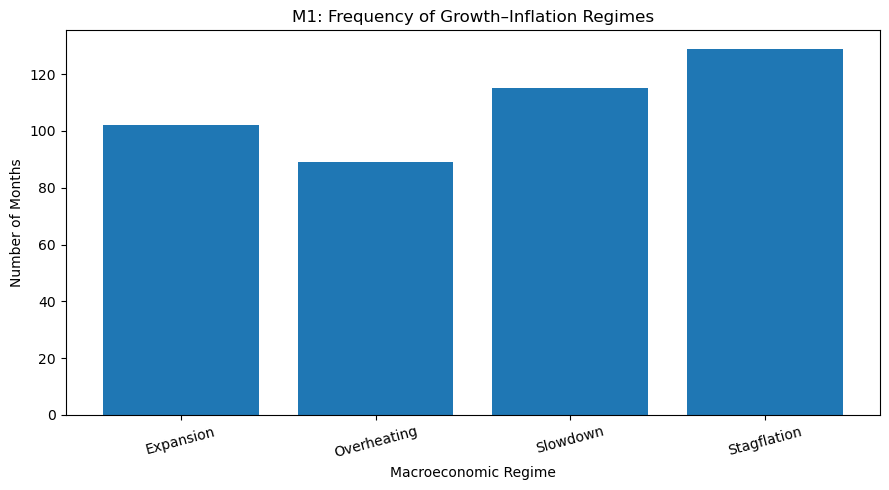

In [24]:
# M1 visualization

order_m1 = [
    "Expansion",
    "Overheating",
    "Slowdown",
    "Stagflation"
]

counts = (
    m1["Regime_M1"]
    .value_counts()
    .reindex(order_m1)
    .fillna(0)
)

plt.figure(figsize=(9,5))

plt.bar(
    counts.index,
    counts.values
)

plt.title("M1: Frequency of Growth–Inflation Regimes")
plt.ylabel("Number of Months")
plt.xlabel("Macroeconomic Regime")

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

### M2 — Growth Index × Pressure Index

- **Growth Index:** higher industrial-production growth, lower unemployment, and a stronger term spread imply stronger growth.
- **Pressure Index:** higher VIX, wider credit spreads, higher inflation, and larger short-rate changes imply greater macro-financial pressure.

In [25]:
# ============================================================
# M2 — GROWTH INDEX × PRESSURE INDEX
# ============================================================
m2 = regime_base.dropna(subset=macro7).copy()
m2_train = regime_train.dropna(subset=macro7).copy()

scaler_m2 = StandardScaler()
scaler_m2.fit(m2_train[macro7])

z = pd.DataFrame(
    scaler_m2.transform(m2[macro7]),
    index=m2.index,
    columns=macro7
)

# Growth: stronger IP growth and term spread; lower unemployment.
m2["Growth_Index"] = (
    z["IP_Growth_lag1"]
    + z["Term_Spread"]
    - z["Unemployment_lag1"]
) / 3

# Pressure: higher volatility, credit stress, inflation and short-rate movement.
m2["Pressure_Index"] = (
    z["VIX"]
    + z["Credit_Spread"]
    + z["Inflation_lag1"]
    + z["Treasury_2Y_change"].abs()
) / 4

# Estimate quadrant cutoffs from the training sample using the same scaler.
z_train = pd.DataFrame(
    scaler_m2.transform(m2_train[macro7]),
    index=m2_train.index,
    columns=macro7
)
growth_train = (z_train["IP_Growth_lag1"] + z_train["Term_Spread"] - z_train["Unemployment_lag1"]) / 3
pressure_train = (z_train["VIX"] + z_train["Credit_Spread"] + z_train["Inflation_lag1"] + z_train["Treasury_2Y_change"].abs()) / 4

g_cut = growth_train.median()
p_cut = pressure_train.median()

def classify_m2(row):
    high_growth = row["Growth_Index"] > g_cut
    high_pressure = row["Pressure_Index"] > p_cut

    if high_growth and not high_pressure:
        return "Strong Growth / Low Pressure"
    elif high_growth and high_pressure:
        return "Strong Growth / High Pressure"
    elif (not high_growth) and high_pressure:
        return "Weak Growth / High Pressure"
    else:
        return "Weak Growth / Low Pressure"

m2["Regime_M2"] = m2.apply(classify_m2, axis=1)

print("M2 regime counts:")
print(m2["Regime_M2"].value_counts())
display(m2.groupby("Regime_M2")[factor_next].mean().round(3))


M2 regime counts:
Regime_M2
Strong Growth / Low Pressure     128
Weak Growth / Low Pressure       115
Weak Growth / High Pressure      108
Strong Growth / High Pressure     84
Name: count, dtype: int64


,MKT_RF_next,SMB_next,HML_next,RMW_next,CMA_next,MOM_next
Regime_M2,,,,,,
Strong Growth / High Pressure,0.800,0.694,0.167,0.137,0.434,0.772
Strong Growth / Low Pressure,0.708,-0.218,0.229,0.211,0.039,0.798
Weak Growth / High Pressure,1.049,0.205,0.173,0.758,0.323,-0.305
Weak Growth / Low Pressure,0.533,-0.153,0.094,0.180,-0.015,0.621


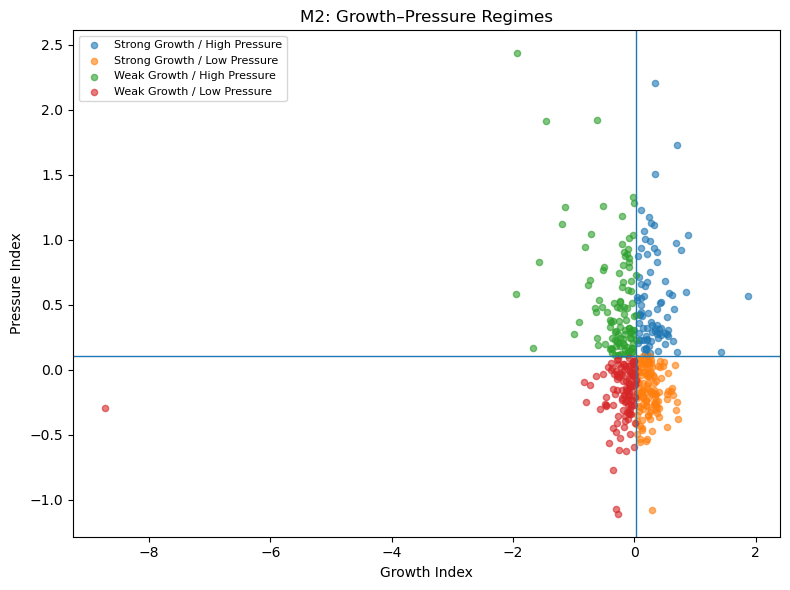

In [26]:
# M2 visualization
plt.figure(figsize=(8,6))
for regime, group in m2.groupby("Regime_M2"):
    plt.scatter(group["Growth_Index"], group["Pressure_Index"], s=20, alpha=0.6, label=regime)

plt.axvline(g_cut, linewidth=1)
plt.axhline(p_cut, linewidth=1)
plt.xlabel("Growth Index")
plt.ylabel("Pressure Index")
plt.title("M2: Growth–Pressure Regimes")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


### M3 — PCA + K-means Four-Cluster Classification

1. Standardize the seven macro variables.
2. Apply PCA to reduce correlated macro information to a small number of components.
3. Apply K-means with `k=4`.
4. Inspect cluster centroids to assign economic interpretations afterward.

In [27]:
# ============================================================
# M3 — PCA + K-MEANS
# ============================================================
m3 = regime_base.dropna(subset=macro7).copy()
m3_train = regime_train.dropna(subset=macro7).copy()

scaler_m3 = StandardScaler()
X_train_std = scaler_m3.fit_transform(m3_train[macro7])
X_all_std = scaler_m3.transform(m3[macro7])

# Keep enough PCs to explain at least 80% of training variance.
pca_full = PCA().fit(X_train_std)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_pc = int(np.argmax(cumvar >= 0.80) + 1)

pca = PCA(n_components=n_pc)
X_train_pca = pca.fit_transform(X_train_std)
X_all_pca = pca.transform(X_all_std)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=50)
kmeans.fit(X_train_pca)
m3["Cluster_M3"] = kmeans.predict(X_all_pca)

print("Number of PCs retained:", n_pc)
print("Cumulative explained variance:", round(pca.explained_variance_ratio_.sum(), 4))
print("\nM3 cluster counts:")
print(m3["Cluster_M3"].value_counts().sort_index())

# Economic interpretation: standardized original-variable centroids.
centroids = pd.DataFrame(index=range(4), columns=macro7, dtype=float)
for k in range(4):
    idx = m3["Cluster_M3"] == k
    centroids.loc[k] = pd.DataFrame(
        X_all_std[idx],
        columns=macro7
    ).mean().values

print("\nStandardized macro characteristics by cluster:")
display(centroids.round(2))

print("\nAverage next-month factor returns by cluster:")
display(m3.groupby("Cluster_M3")[factor_next].mean().round(3))

sil = silhouette_score(X_all_pca, m3["Cluster_M3"])
print("\nSilhouette score:", round(sil, 3))


Number of PCs retained: 4
Cumulative explained variance: 0.8632

M3 cluster counts:
Cluster_M3
0    124
1    136
2     11
3    164
Name: count, dtype: int64

Standardized macro characteristics by cluster:


,VIX,Credit_Spread,Term_Spread,Treasury_2Y_change,Inflation_lag1,Unemployment_lag1,IP_Growth_lag1
0,-0.09,0.48,0.96,-0.07,-0.14,1.01,0.23
1,-0.00,-0.16,-0.71,-0.56,0.24,-0.81,-0.43
2,2.92,3.21,0.56,-0.53,-2.23,1.16,-4.55
3,-0.49,-0.46,-0.61,0.78,0.06,-0.68,0.30



Average next-month factor returns by cluster:


,MKT_RF_next,SMB_next,HML_next,RMW_next,CMA_next,MOM_next
Cluster_M3,,,,,,
0,1.284,0.448,0.249,0.112,0.366,0.398
1,0.467,-0.230,-0.006,0.468,0.056,0.381
2,-0.779,0.415,-2.399,0.580,-0.562,-3.802
3,0.721,0.038,0.422,0.349,0.169,0.889



Silhouette score: 0.213


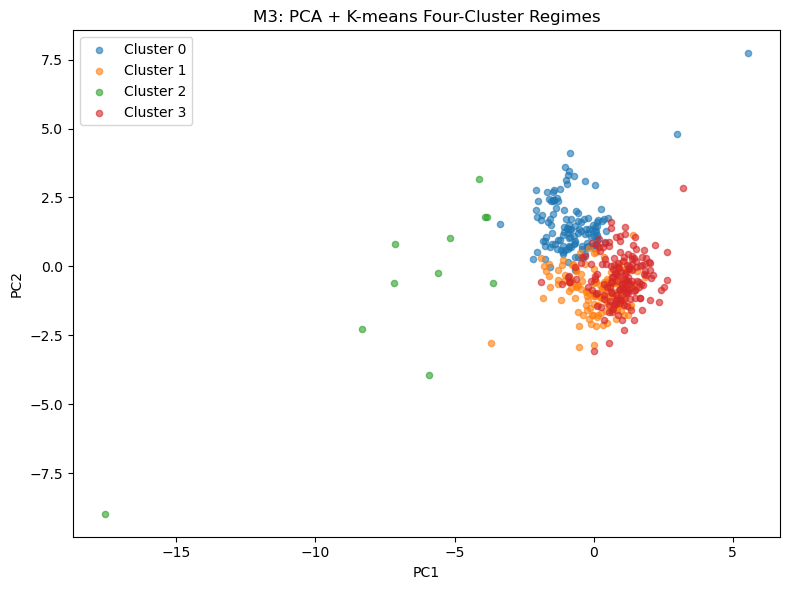

In [28]:
# M3 visualization: first two PCs
plot_pca = PCA(n_components=2)
X_plot = plot_pca.fit_transform(X_all_std)

plt.figure(figsize=(8,6))
for k in sorted(m3["Cluster_M3"].unique()):
    mask = m3["Cluster_M3"].values == k
    plt.scatter(X_plot[mask,0], X_plot[mask,1], s=20, alpha=0.6, label=f"Cluster {k}")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("M3: PCA + K-means Four-Cluster Regimes")
plt.legend()
plt.tight_layout()
plt.show()


In [29]:
# ============================================================
# QUICK COMPARISON OUTPUT
# ============================================================
comparison = pd.DataFrame({
    "Method": ["M1 Growth × Inflation", "M2 Growth × Pressure", "M3 PCA + K-means"],
    "Number_of_states": [
        m1["Regime_M1"].nunique(),
        m2["Regime_M2"].nunique(),
        m3["Cluster_M3"].nunique()
    ],
    "Uses_all_7_macro_variables": ["No", "Yes", "Yes"],
    "Interpretability": ["Very High", "High", "Medium"],
    "Recommended_role": ["Main specification", "Robustness check 1", "Robustness check 2"]
})
display(comparison)


,Method,Number_of_states,Uses_all_7_macro_variables,Interpretability,Recommended_role
0,M1 Growth × Inflation,4,No,Very High,Main specification
1,M2 Growth × Pressure,4,Yes,High,Robustness check 1
2,M3 PCA + K-means,4,Yes,Medium,Robustness check 2


In [30]:
# ============================================================
# M1 VALIDATION 1 — DESCRIPTIVE STATISTICS BY REGIME
# ============================================================

from scipy import stats

m1_order = [
    "Expansion",
    "Overheating",
    "Slowdown",
    "Stagflation"
]

summary_rows = []

for regime in m1_order:

    sub = m1.loc[
        m1["Regime_M1"] == regime,
        factor_next
    ]

    for factor in factor_next:

        x = sub[factor].dropna()

        mean_return = x.mean()
        std_return = x.std(ddof=1)

        t_stat = (
            mean_return / (std_return / np.sqrt(len(x)))
            if len(x) > 1 and std_return > 0
            else np.nan
        )

        summary_rows.append({
            "Regime": regime,
            "Factor": factor.replace("_next", ""),
            "N": len(x),
            "Mean": mean_return,
            "Std": std_return,
            "Median": x.median(),
            "T_stat_vs_0": t_stat
        })

m1_regime_stats = pd.DataFrame(summary_rows)

display(
    m1_regime_stats.round({
        "Mean": 3,
        "Std": 3,
        "Median": 3,
        "T_stat_vs_0": 2
    })
)

,Regime,Factor,N,Mean,Std,Median,T_stat_vs_0
0,Expansion,MKT_RF,102,1.211,3.963,1.480,3.09
1,Expansion,SMB,102,0.122,3.215,-0.305,0.38
2,Expansion,HML,102,-0.120,2.651,-0.055,-0.46
3,Expansion,RMW,102,-0.002,2.078,0.220,-0.01
4,Expansion,CMA,102,0.008,1.888,-0.050,0.04
5,Expansion,MOM,102,0.847,3.616,0.410,2.36
6,Overheating,MKT_RF,89,0.132,4.135,0.490,0.30
7,Overheating,SMB,89,-0.445,3.451,-0.350,-1.22
8,Overheating,HML,89,0.830,3.768,0.370,2.08
9,Overheating,RMW,89,0.666,3.341,0.770,1.88


In [31]:
# ============================================================
# M1 VALIDATION 2 — MEAN RETURN TABLE
# ============================================================

m1_mean_table = (
    m1_regime_stats
    .pivot(
        index="Regime",
        columns="Factor",
        values="Mean"
    )
    .reindex(m1_order)
)

print("Average next-month factor returns by M1 regime:")

display(
    m1_mean_table.round(3)
)

Average next-month factor returns by M1 regime:


Factor,CMA,HML,MKT_RF,MOM,RMW,SMB
Regime,,,,,,
Expansion,0.008,-0.120,1.211,0.847,-0.002,0.122
Overheating,0.635,0.830,0.132,0.791,0.666,-0.445
Slowdown,0.240,-0.371,0.614,0.334,0.015,0.255
Stagflation,-0.080,0.418,0.981,0.079,0.622,0.255


In [32]:
# ============================================================
# M1 VALIDATION 3 — ANOVA + KRUSKAL-WALLIS TESTS
# ============================================================

test_rows = []

for factor in factor_next:

    groups = [
        m1.loc[
            m1["Regime_M1"] == regime,
            factor
        ].dropna().values

        for regime in m1_order
    ]

    # --------------------------------
    # One-way ANOVA
    # H0: all 4 regime means are equal
    # --------------------------------
    f_stat, anova_p = stats.f_oneway(*groups)

    # --------------------------------
    # Kruskal-Wallis
    # Non-parametric robustness test
    # --------------------------------
    h_stat, kw_p = stats.kruskal(*groups)

    test_rows.append({
        "Factor": factor.replace("_next", ""),
        "ANOVA_F": f_stat,
        "ANOVA_p": anova_p,
        "Kruskal_H": h_stat,
        "Kruskal_p": kw_p
    })

m1_regime_tests = pd.DataFrame(test_rows)

display(
    m1_regime_tests.round({
        "ANOVA_F": 3,
        "ANOVA_p": 4,
        "Kruskal_H": 3,
        "Kruskal_p": 4
    })
)

,Factor,ANOVA_F,ANOVA_p,Kruskal_H,Kruskal_p
0,MKT_RF,1.118,0.3414,4.178,0.2429
1,SMB,1.150,0.3288,5.828,0.1203
2,HML,2.871,0.0361,5.687,0.1279
3,RMW,2.017,0.1108,9.333,0.0252
4,CMA,2.143,0.0941,4.870,0.1816
5,MOM,0.689,0.5592,0.212,0.9756


In [33]:
# ============================================================
# M1 VALIDATION 4 — EVIDENCE SUMMARY
# ============================================================

def evidence_label(row):

    anova_sig = row["ANOVA_p"] < 0.05
    kw_sig = row["Kruskal_p"] < 0.05

    if anova_sig and kw_sig:
        return "Strong evidence"

    elif anova_sig or kw_sig:
        return "Mixed evidence"

    else:
        return "No 5% evidence"


evidence_table = m1_regime_tests.copy()

evidence_table["Regime_dependence"] = (
    evidence_table.apply(
        evidence_label,
        axis=1
    )
)

display(
    evidence_table[
        [
            "Factor",
            "ANOVA_p",
            "Kruskal_p",
            "Regime_dependence"
        ]
    ].round(4)
)

,Factor,ANOVA_p,Kruskal_p,Regime_dependence
0,MKT_RF,0.3414,0.2429,No 5% evidence
1,SMB,0.3288,0.1203,No 5% evidence
2,HML,0.0361,0.1279,Mixed evidence
3,RMW,0.1108,0.0252,Mixed evidence
4,CMA,0.0941,0.1816,No 5% evidence
5,MOM,0.5592,0.9756,No 5% evidence


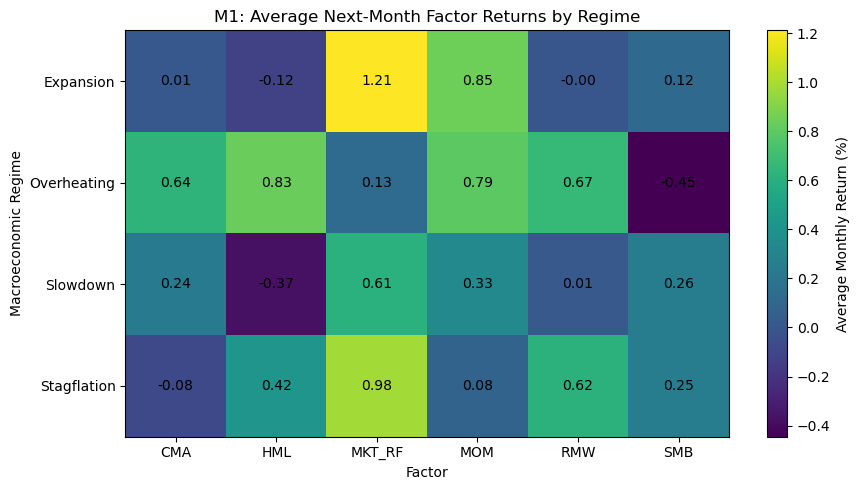

In [34]:
# ============================================================
# M1 VALIDATION 5 — FACTOR RETURN HEATMAP
# ============================================================

heat = m1_mean_table.copy()

fig, ax = plt.subplots(figsize=(9, 5))

im = ax.imshow(
    heat.values,
    aspect="auto"
)

# Axis labels
ax.set_xticks(
    np.arange(len(heat.columns))
)

ax.set_xticklabels(
    heat.columns
)

ax.set_yticks(
    np.arange(len(heat.index))
)

ax.set_yticklabels(
    heat.index
)

# Titles
ax.set_title(
    "M1: Average Next-Month Factor Returns by Regime"
)

ax.set_xlabel("Factor")
ax.set_ylabel("Macroeconomic Regime")

# Add numerical values
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):

        ax.text(
            j,
            i,
            f"{heat.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

fig.colorbar(
    im,
    ax=ax,
    label="Average Monthly Return (%)"
)

plt.tight_layout()
plt.show()

In [35]:
# ============================================================
# M1 VALIDATION 6 — TUKEY HSD PAIRWISE COMPARISONS
# ============================================================

from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Focus on HML and RMW because they showed
# evidence of regime dependence in the previous tests.

for factor in ["HML_next", "RMW_next"]:

    temp = m1[
        ["Regime_M1", factor]
    ].dropna()

    tukey = pairwise_tukeyhsd(
        endog=temp[factor],
        groups=temp["Regime_M1"],
        alpha=0.05
    )

    print("=" * 70)
    print(f"Tukey HSD pairwise comparisons: {factor.replace('_next', '')}")
    print("=" * 70)

    print(tukey)
    print()

Tukey HSD pairwise comparisons: HML
     Multiple Comparison of Means - Tukey HSD, FWER=0.05      
   group1      group2   meandiff p-adj   lower   upper  reject
--------------------------------------------------------------
  Expansion Overheating   0.9494 0.1761 -0.2528  2.1515  False
  Expansion    Slowdown  -0.2516 0.9393 -1.3788  0.8756  False
  Expansion Stagflation   0.5382 0.5864 -0.5599  1.6362  False
Overheating    Slowdown   -1.201 0.0417  -2.371 -0.0309   True
Overheating Stagflation  -0.4112 0.7895 -1.5532  0.7308  False
   Slowdown Stagflation   0.7898 0.2226 -0.2731  1.8526  False
--------------------------------------------------------------

Tukey HSD pairwise comparisons: RMW
     Multiple Comparison of Means - Tukey HSD, FWER=0.05     
   group1      group2   meandiff p-adj   lower  upper  reject
-------------------------------------------------------------
  Expansion Overheating   0.6674  0.318 -0.3373  1.672  False
  Expansion    Slowdown   0.0168    1.0 -0.9252 0

In [36]:
# ============================================================
# MODELING STEP 7 — RIDGE / ELASTIC NET
# Time-series-safe hyperparameter tuning
# ============================================================

import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV, ElasticNetCV
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error


# ------------------------------------------------------------
# 1. Final predictors and targets
# ------------------------------------------------------------

predictor_columns = [
    "VIX",
    "Credit_Spread",
    "Term_Spread",
    "Treasury_2Y_change",
    "Inflation_lag1",
    "Unemployment_lag1",
    "IP_Growth_lag1"
]

target_columns = [
    "MKT_RF_next",
    "SMB_next",
    "HML_next",
    "RMW_next",
    "CMA_next",
    "MOM_next"
]


# ------------------------------------------------------------
# 2. Chronological Train / Validation / Test split
# ------------------------------------------------------------

model_data = model_data.sort_index().copy()

n = len(model_data)

train_end = int(n * 0.60)
val_end   = int(n * 0.80)

train_data = model_data.iloc[:train_end].copy()
val_data   = model_data.iloc[train_end:val_end].copy()
test_data  = model_data.iloc[val_end:].copy()

print("Train:", train_data.index.min(), "to", train_data.index.max(),
      "| N =", len(train_data))

print("Validation:", val_data.index.min(), "to", val_data.index.max(),
      "| N =", len(val_data))

print("Test:", test_data.index.min(), "to", test_data.index.max(),
      "| N =", len(test_data))


# ------------------------------------------------------------
# 3. X matrices
# ------------------------------------------------------------

X_train = train_data[predictor_columns]
X_val   = val_data[predictor_columns]
X_test  = test_data[predictor_columns]


# ------------------------------------------------------------
# 4. Standardize predictors
# IMPORTANT: scaler fitted ONLY on training data
# ------------------------------------------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)

X_test_scaled = scaler.transform(X_test)


# ------------------------------------------------------------
# 5. Time-series cross-validation
# ------------------------------------------------------------

tscv = TimeSeriesSplit(n_splits=5)


# ------------------------------------------------------------
# 6. Hyperparameter grids
# ------------------------------------------------------------

ridge_alphas = np.logspace(-4, 4, 100)

elastic_alphas = np.logspace(-4, 1, 100)

elastic_l1_ratios = [
    0.1,
    0.25,
    0.5,
    0.75,
    0.9,
    0.95
]


# ------------------------------------------------------------
# 7. Estimate Ridge and Elastic Net separately for each factor
# ------------------------------------------------------------

results = []

ridge_models = {}
elastic_models = {}

for target in target_columns:

    print("\n========================================")
    print("Target:", target)
    print("========================================")

    y_train = train_data[target]
    y_val   = val_data[target]

    # --------------------------------------------------------
    # Historical mean benchmark
    # --------------------------------------------------------

    historical_mean = y_train.mean()

    benchmark_pred = np.repeat(
        historical_mean,
        len(y_val)
    )

    benchmark_mse = mean_squared_error(
        y_val,
        benchmark_pred
    )

    benchmark_rmse = np.sqrt(benchmark_mse)

    benchmark_mae = mean_absolute_error(
        y_val,
        benchmark_pred
    )


    # --------------------------------------------------------
    # RIDGE
    # --------------------------------------------------------

    ridge = RidgeCV(
        alphas=ridge_alphas,
        cv=tscv
    )

    ridge.fit(
        X_train_scaled,
        y_train
    )

    ridge_pred = ridge.predict(
        X_val_scaled
    )

    ridge_mse = mean_squared_error(
        y_val,
        ridge_pred
    )

    ridge_rmse = np.sqrt(ridge_mse)

    ridge_mae = mean_absolute_error(
        y_val,
        ridge_pred
    )

    ridge_oos_r2 = (
        1 - ridge_mse / benchmark_mse
    )

    ridge_direction = np.mean(
        np.sign(ridge_pred)
        ==
        np.sign(y_val.values)
    )

    ridge_models[target] = ridge


    # --------------------------------------------------------
    # ELASTIC NET
    # --------------------------------------------------------

    elastic = ElasticNetCV(
        alphas=elastic_alphas,
        l1_ratio=elastic_l1_ratios,
        cv=tscv,
        max_iter=50000
    )

    elastic.fit(
        X_train_scaled,
        y_train
    )

    elastic_pred = elastic.predict(
        X_val_scaled
    )

    elastic_mse = mean_squared_error(
        y_val,
        elastic_pred
    )

    elastic_rmse = np.sqrt(elastic_mse)

    elastic_mae = mean_absolute_error(
        y_val,
        elastic_pred
    )

    elastic_oos_r2 = (
        1 - elastic_mse / benchmark_mse
    )

    elastic_direction = np.mean(
        np.sign(elastic_pred)
        ==
        np.sign(y_val.values)
    )

    elastic_models[target] = elastic


    # --------------------------------------------------------
    # Save benchmark
    # --------------------------------------------------------

    results.append({
        "Factor": target,
        "Model": "Historical Mean",
        "RMSE": benchmark_rmse,
        "MAE": benchmark_mae,
        "OOS_R2": 0.0,
        "Directional_Accuracy": np.nan,
        "Alpha": np.nan,
        "L1_Ratio": np.nan
    })


    # --------------------------------------------------------
    # Save Ridge
    # --------------------------------------------------------

    results.append({
        "Factor": target,
        "Model": "Ridge",
        "RMSE": ridge_rmse,
        "MAE": ridge_mae,
        "OOS_R2": ridge_oos_r2,
        "Directional_Accuracy": ridge_direction,
        "Alpha": ridge.alpha_,
        "L1_Ratio": np.nan
    })


    # --------------------------------------------------------
    # Save Elastic Net
    # --------------------------------------------------------

    results.append({
        "Factor": target,
        "Model": "Elastic Net",
        "RMSE": elastic_rmse,
        "MAE": elastic_mae,
        "OOS_R2": elastic_oos_r2,
        "Directional_Accuracy": elastic_direction,
        "Alpha": elastic.alpha_,
        "L1_Ratio": elastic.l1_ratio_
    })


# ------------------------------------------------------------
# 8. Results table
# ------------------------------------------------------------

step7_results = pd.DataFrame(results)

print("\n")
print("=" * 80)
print("STEP 7 — VALIDATION RESULTS")
print("=" * 80)

print(
    step7_results.round(4).to_string(index=False)
)


Train: 1990-03-31 00:00:00 to 2011-11-30 00:00:00 | N = 261
Validation: 2011-12-31 00:00:00 to 2019-02-28 00:00:00 | N = 87
Test: 2019-03-31 00:00:00 to 2026-06-30 00:00:00 | N = 87

Target: MKT_RF_next

Target: SMB_next

Target: HML_next

Target: RMW_next

Target: CMA_next

Target: MOM_next


STEP 7 — VALIDATION RESULTS
     Factor           Model   RMSE    MAE  OOS_R2  Directional_Accuracy      Alpha  L1_Ratio
MKT_RF_next Historical Mean 3.2844 2.5140  0.0000                   NaN        NaN       NaN
MKT_RF_next           Ridge 3.2847 2.5153 -0.0002                0.7241 10000.0000       NaN
MKT_RF_next     Elastic Net 3.2844 2.5140  0.0000                0.7241    10.0000      0.10
   SMB_next Historical Mean 2.3581 1.8796  0.0000                   NaN        NaN       NaN
   SMB_next           Ridge 2.3762 1.8824 -0.0155                0.5287   509.4138       NaN
   SMB_next     Elastic Net 2.3643 1.8776 -0.0053                0.5287     0.8697      0.25
   HML_next Historical Mea

In [37]:
 # ============================================================
# STEP 8A — FREEZE STEP 7 HYPERPARAMETERS
# Run this BEFORE Modeling Step 8
# ============================================================

frozen_params = {}

for target in target_columns:

    frozen_params[target] = {

        "ridge_alpha":
            ridge_models[target].alpha_,

        "elastic_alpha":
            elastic_models[target].alpha_,

        "elastic_l1_ratio":
            elastic_models[target].l1_ratio_
    }


frozen_params_df = pd.DataFrame(
    frozen_params
).T


print("=" * 70)
print("FROZEN STEP 7 HYPERPARAMETERS")
print("=" * 70)

display(
    frozen_params_df.round(4)
)

FROZEN STEP 7 HYPERPARAMETERS


,ridge_alpha,elastic_alpha,elastic_l1_ratio
MKT_RF_next,10000.0000,10.0000,0.10
SMB_next,509.4138,0.8697,0.25
HML_next,10000.0000,10.0000,0.10
RMW_next,3274.5492,10.0000,0.10
CMA_next,10000.0000,0.3430,0.75
MOM_next,10000.0000,0.8697,0.90


In [38]:
# ============================================================
# MODELING STEP 8 — EXPANDING WINDOW OOS (Important)
# Professor Suggestion #2 preparation
#
# Goal:
# Use information available at time t to forecast each
# factor return at t+1, and SAVE the monthly forecasts
# for portfolio allocation in Steps 9–12.
# ============================================================

import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_error


# ------------------------------------------------------------
# 1. Use the beginning of the TEST period as OOS start
#
# From Step 7:
# Train      = 60%
# Validation = 20%
# Test       = 20%
#
# Step 8 starts at the beginning of the test sample.
# ------------------------------------------------------------

initial_train = len(train_data) + len(val_data)

print("Initial expanding-window observations:", initial_train)
print("First OOS date:", model_data.index[initial_train])
print("Last OOS date:", model_data.index[-1])


# ------------------------------------------------------------
# 2. Containers
# ------------------------------------------------------------

step8_results_list = []
forecast_records = []


# ------------------------------------------------------------
# 3. Loop through six factor-return targets
# ------------------------------------------------------------

for target in target_columns:

    print("\n" + "=" * 60)
    print("Expanding OOS target:", target)
    print("=" * 60)

    actual_values = []

    historical_predictions = []
    ols_predictions = []
    ridge_predictions = []
    elastic_predictions = []


    # --------------------------------------------------------
    # 4. Expanding-window loop
    # --------------------------------------------------------

    for i in range(initial_train, len(model_data)):

        # Everything strictly before observation i
        # is available for model estimation.
        train_expanding = model_data.iloc[:i].copy()

        # Observation i is the next OOS observation
        test_one = model_data.iloc[i:i+1].copy()


        X_train = train_expanding[predictor_columns]
        y_train = train_expanding[target]

        X_test = test_one[predictor_columns]
        y_actual = test_one[target].iloc[0]


        # ----------------------------------------------------
        # Historical mean benchmark
        # ----------------------------------------------------

        historical_pred = y_train.mean()


        # ----------------------------------------------------
        # Standardize predictors
        #
        # IMPORTANT:
        # scaler is fitted only on data available before t.
        # ----------------------------------------------------

        scaler = StandardScaler()

        X_train_scaled = scaler.fit_transform(X_train)

        X_test_scaled = scaler.transform(X_test)


        # ----------------------------------------------------
        # OLS
        # ----------------------------------------------------

        ols_model = LinearRegression()

        ols_model.fit(
            X_train_scaled,
            y_train
        )

        ols_pred = ols_model.predict(
            X_test_scaled
        )[0]


        # ----------------------------------------------------
        # Ridge
        #
        # Use frozen Step 7 alpha
        # ----------------------------------------------------

        ridge_alpha = frozen_params[target]["ridge_alpha"]

        ridge_model = Ridge(
            alpha=ridge_alpha
        )

        ridge_model.fit(
            X_train_scaled,
            y_train
        )

        ridge_pred = ridge_model.predict(
            X_test_scaled
        )[0]


        # ----------------------------------------------------
        # Elastic Net
        #
        # Use frozen Step 7 alpha + l1_ratio
        # ----------------------------------------------------

        elastic_alpha = frozen_params[target]["elastic_alpha"]

        elastic_l1_ratio = frozen_params[target]["elastic_l1_ratio"]

        elastic_model = ElasticNet(
            alpha=elastic_alpha,
            l1_ratio=elastic_l1_ratio,
            max_iter=10000
        )

        elastic_model.fit(
            X_train_scaled,
            y_train
        )

        elastic_pred = elastic_model.predict(
            X_test_scaled
        )[0]


        # ----------------------------------------------------
        # 5. Save values for model evaluation
        # ----------------------------------------------------

        actual_values.append(
            y_actual
        )

        historical_predictions.append(
            historical_pred
        )

        ols_predictions.append(
            ols_pred
        )

        ridge_predictions.append(
            ridge_pred
        )

        elastic_predictions.append(
            elastic_pred
        )


        # ----------------------------------------------------
        # 6. Save individual OOS forecasts
        #
        # These observations are needed in Steps 9–12.
        # ----------------------------------------------------

        forecast_records.append({

            "Date":
                model_data.index[i],

            "Factor":
                target,

            "Actual":
                y_actual,

            "Historical_Mean":
                historical_pred,

            "OLS":
                ols_pred,

            "Ridge":
                ridge_pred,

            "Elastic_Net":
                elastic_pred
        })


    # --------------------------------------------------------
    # 7. Convert to arrays
    # --------------------------------------------------------

    actual_values = np.array(
        actual_values
    )

    model_predictions = {

        "Historical_Mean":
            np.array(
                historical_predictions
            ),

        "OLS":
            np.array(
                ols_predictions
            ),

        "Ridge":
            np.array(
                ridge_predictions
            ),

        "Elastic_Net":
            np.array(
                elastic_predictions
            )
    }


    # --------------------------------------------------------
    # 8. Historical-mean MSE for OOS R2 benchmark
    # --------------------------------------------------------

    historical_mse = mean_squared_error(
        actual_values,
        model_predictions[
            "Historical_Mean"
        ]
    )


    # --------------------------------------------------------
    # 9. Evaluate each forecasting model
    # --------------------------------------------------------

    for model_name, prediction in model_predictions.items():

        rmse = np.sqrt(
            mean_squared_error(
                actual_values,
                prediction
            )
        )

        mae = mean_absolute_error(
            actual_values,
            prediction
        )


        if model_name == "Historical_Mean":

            oos_r2 = 0.0

        else:

            model_mse = mean_squared_error(
                actual_values,
                prediction
            )

            oos_r2 = (
                1
                -
                model_mse
                /
                historical_mse
            )


        directional_accuracy = np.mean(

            np.sign(actual_values)

            ==

            np.sign(prediction)

        )


        step8_results_list.append({

            "Factor":
                target,

            "Model":
                model_name,

            "RMSE":
                rmse,

            "MAE":
                mae,

            "OOS_R2":
                oos_r2,

            "Directional_Accuracy":
                directional_accuracy
        })


# ------------------------------------------------------------
# 10. Final Step 8 results
# ------------------------------------------------------------

step8_results = pd.DataFrame(
    step8_results_list
)

step8_forecasts = pd.DataFrame(
    forecast_records
)


print("\n")
print("=" * 90)

print(
    "STEP 8 — FINAL EXPANDING-WINDOW "
    "PSEUDO-OOS RESULTS"
)

print("=" * 90)

display(
    step8_results.round(4)
)


print("\nForecast dataset shape:")

print(
    step8_forecasts.shape
)


print("\nFirst few forecasts:")

display(
    step8_forecasts.head(12)
)

Initial expanding-window observations: 348
First OOS date: 2019-03-31 00:00:00
Last OOS date: 2026-06-30 00:00:00

Expanding OOS target: MKT_RF_next

Expanding OOS target: SMB_next

Expanding OOS target: HML_next

Expanding OOS target: RMW_next

Expanding OOS target: CMA_next

Expanding OOS target: MOM_next


STEP 8 — FINAL EXPANDING-WINDOW PSEUDO-OOS RESULTS


,Factor,Model,RMSE,MAE,OOS_R2,Directional_Accuracy
0,MKT_RF_next,Historical_Mean,4.9898,3.9395,0.0000,0.6207
1,MKT_RF_next,OLS,5.0507,4.0218,-0.0245,0.5287
2,MKT_RF_next,Ridge,4.9908,3.9469,-0.0004,0.6207
3,MKT_RF_next,Elastic_Net,4.9898,3.9395,0.0000,0.6207
4,SMB_next,Historical_Mean,3.1142,2.3591,0.0000,0.4138
5,SMB_next,OLS,3.1266,2.3300,-0.0080,0.4943
6,SMB_next,Ridge,3.0803,2.2982,0.0216,0.5747
7,SMB_next,Elastic_Net,3.1011,2.3342,0.0084,0.5517
8,HML_next,Historical_Mean,4.2227,3.2687,0.0000,0.4598
9,HML_next,OLS,4.1655,3.2277,0.0269,0.5517



Forecast dataset shape:
(522, 7)

First few forecasts:


,Date,Factor,Actual,Historical_Mean,OLS,Ridge,Elastic_Net
0,2019-03-31,MKT_RF_next,3.97,0.673649,-0.537001,0.630541,0.673649
1,2019-04-30,MKT_RF_next,-6.92,0.683095,0.042552,0.661194,0.683095
2,2019-05-31,MKT_RF_next,6.99,0.661371,-0.560719,0.616109,0.661371
3,2019-06-30,MKT_RF_next,1.22,0.679402,-0.219500,0.646970,0.679402
4,2019-07-31,MKT_RF_next,-2.55,0.680937,-0.175619,0.653046,0.680937
5,2019-08-31,MKT_RF_next,1.42,0.671785,-0.347308,0.628265,0.671785
6,2019-09-30,MKT_RF_next,2.07,0.673898,0.557246,0.666762,0.673898
7,2019-10-31,MKT_RF_next,3.87,0.677831,-0.397903,0.638962,0.677831
8,2019-11-30,MKT_RF_next,2.76,0.686798,-0.718580,0.639827,0.686798
9,2019-12-31,MKT_RF_next,-0.09,0.692605,0.421635,0.685500,0.692605


In [39]:
# ============================================================
# STEP 8B — OOS FORECAST ALIGNMENT CHECK
# ============================================================

print("First 12 forecast rows:")

display(
    step8_forecasts[
        [
            "Date",
            "Factor",
            "Actual",
            "Historical_Mean",
            "OLS",
            "Ridge",
            "Elastic_Net"
        ]
    ].head(12)
)


print("\nUnique OOS dates:")

print(
    step8_forecasts["Date"].nunique()
)


print("\nForecasts per date:")

display(
    step8_forecasts
    .groupby("Date")
    .size()
    .head()
)

First 12 forecast rows:


,Date,Factor,Actual,Historical_Mean,OLS,Ridge,Elastic_Net
0,2019-03-31,MKT_RF_next,3.97,0.673649,-0.537001,0.630541,0.673649
1,2019-04-30,MKT_RF_next,-6.92,0.683095,0.042552,0.661194,0.683095
2,2019-05-31,MKT_RF_next,6.99,0.661371,-0.560719,0.616109,0.661371
3,2019-06-30,MKT_RF_next,1.22,0.679402,-0.219500,0.646970,0.679402
4,2019-07-31,MKT_RF_next,-2.55,0.680937,-0.175619,0.653046,0.680937
5,2019-08-31,MKT_RF_next,1.42,0.671785,-0.347308,0.628265,0.671785
6,2019-09-30,MKT_RF_next,2.07,0.673898,0.557246,0.666762,0.673898
7,2019-10-31,MKT_RF_next,3.87,0.677831,-0.397903,0.638962,0.677831
8,2019-11-30,MKT_RF_next,2.76,0.686798,-0.718580,0.639827,0.686798
9,2019-12-31,MKT_RF_next,-0.09,0.692605,0.421635,0.685500,0.692605



Unique OOS dates:
87

Forecasts per date:


Date
2019-03-31    6
2019-04-30    6
2019-05-31    6
2019-06-30    6
2019-07-31    6
dtype: int64

In [40]:
# ============================================================
# STEP 8C — MAKE t AND t+1 TIMING EXPLICIT
# ============================================================

step8_forecasts = step8_forecasts.rename(
    columns={"Date": "Signal_Date"}
)

step8_forecasts["Return_Date"] = (
    step8_forecasts["Signal_Date"]
    + pd.offsets.MonthEnd(1)
)

# Reorder columns
step8_forecasts = step8_forecasts[
    [
        "Signal_Date",
        "Return_Date",
        "Factor",
        "Actual",
        "Historical_Mean",
        "OLS",
        "Ridge",
        "Elastic_Net"
    ]
]

display(step8_forecasts.head(12))

,Signal_Date,Return_Date,Factor,Actual,Historical_Mean,OLS,Ridge,Elastic_Net
0,2019-03-31,2019-04-30,MKT_RF_next,3.97,0.673649,-0.537001,0.630541,0.673649
1,2019-04-30,2019-05-31,MKT_RF_next,-6.92,0.683095,0.042552,0.661194,0.683095
2,2019-05-31,2019-06-30,MKT_RF_next,6.99,0.661371,-0.560719,0.616109,0.661371
3,2019-06-30,2019-07-31,MKT_RF_next,1.22,0.679402,-0.219500,0.646970,0.679402
4,2019-07-31,2019-08-31,MKT_RF_next,-2.55,0.680937,-0.175619,0.653046,0.680937
5,2019-08-31,2019-09-30,MKT_RF_next,1.42,0.671785,-0.347308,0.628265,0.671785
6,2019-09-30,2019-10-31,MKT_RF_next,2.07,0.673898,0.557246,0.666762,0.673898
7,2019-10-31,2019-11-30,MKT_RF_next,3.87,0.677831,-0.397903,0.638962,0.677831
8,2019-11-30,2019-12-31,MKT_RF_next,2.76,0.686798,-0.718580,0.639827,0.686798
9,2019-12-31,2020-01-31,MKT_RF_next,-0.09,0.692605,0.421635,0.685500,0.692605


In [42]:
# ============================================================
# MODELING STEP 9 — STATIC EQUAL-WEIGHTED FACTOR PORTFOLIO
#
# Static benchmark:
# w_i = 1/6 for all six factors
#
# IMPORTANT:
# We use Return_Date because "Actual" is the realized
# next-period factor return.
# ============================================================

factor_order = [
    "MKT_RF_next",
    "SMB_next",
    "HML_next",
    "RMW_next",
    "CMA_next",
    "MOM_next"
]


# ------------------------------------------------------------
# 1. Equal weight
# ------------------------------------------------------------

n_factors = len(factor_order)

static_weight = 1 / n_factors

print(
    "Static weight per factor:",
    round(static_weight, 4)
)


# ------------------------------------------------------------
# 2. Realized OOS factor-return matrix
#
# Return_Date × six factors
# ------------------------------------------------------------

actual_returns = (
    step8_forecasts
    .pivot(
        index="Return_Date",
        columns="Factor",
        values="Actual"
    )
    .reindex(
        columns=factor_order
    )
    .sort_index()
)


print("\nRealized OOS factor returns:")

display(
    actual_returns.head()
)


# ------------------------------------------------------------
# 3. Static 1/6 weights
# ------------------------------------------------------------

static_weights = pd.DataFrame(
    static_weight,
    index=actual_returns.index,
    columns=factor_order
)


print("\nStatic weights:")

display(
    static_weights.head()
)


# ------------------------------------------------------------
# 4. Static portfolio return
# ------------------------------------------------------------

static_return = (
    actual_returns
    *
    static_weights
).sum(axis=1)


static_portfolio = pd.DataFrame({
    "Static_Return": static_return
})


print("\nStatic portfolio returns:")

display(
    static_portfolio.head()
)


# ------------------------------------------------------------
# 5. Basic checks
# ------------------------------------------------------------

print(
    "\nNumber of OOS return months:",
    len(actual_returns)
)

print(
    "Weight sum:",
    static_weights.iloc[0].sum()
)

Static weight per factor: 0.1667

Realized OOS factor returns:


Factor,MKT_RF_next,SMB_next,HML_next,RMW_next,CMA_next,MOM_next
Return_Date,,,,,,
2019-04-30,3.97,-1.11,2.13,1.57,-2.19,-2.91
2019-05-31,-6.92,-1.51,-2.36,-0.51,1.75,7.56
2019-06-30,6.99,0.19,-0.72,0.49,-0.51,-2.26
2019-07-31,1.22,-1.82,0.50,-0.13,0.37,2.93
2019-08-31,-2.55,-3.25,-4.77,0.53,-0.62,7.47



Static weights:


,MKT_RF_next,SMB_next,HML_next,RMW_next,CMA_next,MOM_next
Return_Date,,,,,,
2019-04-30,0.166667,0.166667,0.166667,0.166667,0.166667,0.166667
2019-05-31,0.166667,0.166667,0.166667,0.166667,0.166667,0.166667
2019-06-30,0.166667,0.166667,0.166667,0.166667,0.166667,0.166667
2019-07-31,0.166667,0.166667,0.166667,0.166667,0.166667,0.166667
2019-08-31,0.166667,0.166667,0.166667,0.166667,0.166667,0.166667



Static portfolio returns:


,Static_Return
Return_Date,
2019-04-30,0.243333
2019-05-31,-0.331667
2019-06-30,0.696667
2019-07-31,0.511667
2019-08-31,-0.531667



Number of OOS return months: 87
Weight sum: 0.9999999999999999


In [43]:
# ============================================================
# MODELING STEP 10 — DYNAMIC FORECAST-BASED FACTOR ALLOCATION
# ============================================================

# ------------------------------------------------------------
# 1. Macro-based ensemble forecast
# ------------------------------------------------------------

step8_forecasts[
    "Macro_Forecast"
] = (

    step8_forecasts["OLS"]

    +

    step8_forecasts["Ridge"]

    +

    step8_forecasts["Elastic_Net"]

) / 3


# ------------------------------------------------------------
# 2. Date × Factor forecast matrix
# ------------------------------------------------------------

forecast_matrix = (
    step8_forecasts
    .pivot(
        index="Return_Date",
        columns="Factor",
        values="Macro_Forecast"
    )
    .reindex(
        columns=factor_order
    )
    .sort_index()
)

print(
    "Macro forecast matrix:"
)

display(
    forecast_matrix.head()
)


# ------------------------------------------------------------
# 3. Long-only positive forecast signal
#
# Negative expected return -> weight score = 0
# Positive expected return -> positive score
# ------------------------------------------------------------

positive_scores = (
    forecast_matrix
    .clip(lower=0)
)


# ------------------------------------------------------------
# 4. Convert scores into weights
# ------------------------------------------------------------

score_sum = (
    positive_scores
    .sum(axis=1)
)


dynamic_weights = (

    positive_scores

    .div(
        score_sum.replace(
            0,
            np.nan
        ),
        axis=0
    )
)


# If ALL forecasts <= 0:
# fall back to static 1/6 allocation

dynamic_weights = (
    dynamic_weights
    .fillna(
        static_weight
    )
)


# ------------------------------------------------------------
# 5. Check weights
# ------------------------------------------------------------

print(
    "First dynamic weights:"
)

display(
    dynamic_weights.head(10)
)


print(
    "\nWeight sums:"
)

display(
    dynamic_weights
    .sum(axis=1)
    .head(10)
)

Macro forecast matrix:


Factor,MKT_RF_next,SMB_next,HML_next,RMW_next,CMA_next,MOM_next
Return_Date,,,,,,
2019-04-30,0.255730,0.037966,0.363713,0.513295,0.253247,0.573145
2019-05-31,0.462280,0.038339,0.472600,0.472216,0.241367,0.496815
2019-06-30,0.238921,-0.016492,0.343755,0.560219,0.228269,0.576348
2019-07-31,0.368957,0.011258,0.096435,0.485653,0.131465,0.516430
2019-08-31,0.386121,0.077679,0.123057,0.282969,0.199184,0.813256


First dynamic weights:


Factor,MKT_RF_next,SMB_next,HML_next,RMW_next,CMA_next,MOM_next
Return_Date,,,,,,
2019-04-30,0.128051,0.019010,0.182121,0.257021,0.126808,0.286989
2019-05-31,0.211704,0.017558,0.216430,0.216254,0.110536,0.227519
2019-06-30,0.122680,0.000000,0.176510,0.287659,0.117211,0.295941
2019-07-31,0.229138,0.006992,0.059890,0.301611,0.081645,0.320725
2019-08-31,0.205136,0.041269,0.065377,0.150334,0.105821,0.432062
2019-09-30,0.180574,0.000000,0.081718,0.309268,0.097926,0.330514
2019-10-31,0.330263,0.019586,0.100604,0.115062,0.119071,0.315414
2019-11-30,0.164385,0.000000,0.106584,0.240886,0.111565,0.376580
2019-12-31,0.097082,0.007138,0.164681,0.224930,0.123870,0.382298



Weight sums:


Return_Date
2019-04-30    1.0
2019-05-31    1.0
2019-06-30    1.0
2019-07-31    1.0
2019-08-31    1.0
2019-09-30    1.0
2019-10-31    1.0
2019-11-30    1.0
2019-12-31    1.0
2020-01-31    1.0
dtype: float64

In [44]:
# ============================================================
# STEP 10B — WEIGHT VALIDATION
# ============================================================

print("Dynamic weight summary:")

display(
    dynamic_weights.describe().T[
        ["mean", "std", "min", "max"]
    ].round(4)
)


print("\nMinimum weight:")

print(
    dynamic_weights.min().min()
)


print("\nMaximum weight:")

print(
    dynamic_weights.max().max()
)


print("\nWeight-sum range:")

print(
    dynamic_weights.sum(axis=1).min(),
    dynamic_weights.sum(axis=1).max()
)

Dynamic weight summary:


,mean,std,min,max
Factor,,,,
MKT_RF_next,0.3257,0.1401,0.0,0.8363
SMB_next,0.0096,0.0204,0.0,0.1206
HML_next,0.0929,0.0840,0.0,0.3502
RMW_next,0.1965,0.0839,0.0,0.5350
CMA_next,0.0947,0.0510,0.0,0.2234
MOM_next,0.2806,0.1250,0.0,0.4657



Minimum weight:
0.0

Maximum weight:
0.8363253290311214

Weight-sum range:
0.9999999999999998 1.0000000000000002


In [45]:
# ============================================================
# MODELING STEP 11 — STATIC VS DYNAMIC GROSS PERFORMANCE
# ============================================================

# ------------------------------------------------------------
# 1. Align realized returns and dynamic weights
# ------------------------------------------------------------

common_dates = (
    actual_returns.index
    .intersection(
        dynamic_weights.index
    )
)


actual_oos = (
    actual_returns
    .loc[common_dates]
)


weights_dynamic = (
    dynamic_weights
    .loc[common_dates]
)


# ------------------------------------------------------------
# 2. Realized dynamic portfolio return
# ------------------------------------------------------------

dynamic_gross_return = (

    actual_oos
    *
    weights_dynamic

).sum(axis=1)


# ------------------------------------------------------------
# 3. Realized static benchmark return
# ------------------------------------------------------------

static_return = (

    actual_oos
    *
    static_weight

).sum(axis=1)


portfolio_returns = pd.DataFrame({

    "Static":
        static_return,

    "Dynamic_Gross":
        dynamic_gross_return
})


display(
    portfolio_returns.head()
)

,Static,Dynamic_Gross
Return_Date,,
2019-04-30,0.243333,0.165852
2019-05-31,-0.331667,-0.199086
2019-06-30,0.696667,0.142794
2019-07-31,0.511667,1.227491
2019-08-31,-0.531667,2.272502


In [46]:
# ------------------------------------------------------------
# Performance-statistics function
#
# Factor returns are stored in percentage units.
# ------------------------------------------------------------

def portfolio_stats(return_series):

    r = (
        return_series
        .dropna()
        / 100
    )

    n_months = len(r)


    cumulative_return = (
        (1 + r).prod()
        - 1
    )


    annualized_return = (

        (1 + cumulative_return)
        ** (12 / n_months)

        - 1
    )


    annualized_volatility = (
        r.std(ddof=1)
        *
        np.sqrt(12)
    )


    sharpe = (

        annualized_return
        /
        annualized_volatility

        if annualized_volatility > 0

        else np.nan
    )


    wealth = (
        1 + r
    ).cumprod()


    running_max = (
        wealth
        .cummax()
    )


    drawdown = (
        wealth
        /
        running_max
        - 1
    )


    max_drawdown = (
        drawdown.min()
    )


    return pd.Series({

        "Annualized_Return":
            annualized_return,

        "Annualized_Volatility":
            annualized_volatility,

        "Sharpe":
            sharpe,

        "Cumulative_Return":
            cumulative_return,

        "Max_Drawdown":
            max_drawdown
    })


gross_performance = pd.DataFrame({

    "Static_1_6":
        portfolio_stats(
            portfolio_returns[
                "Static"
            ]
        ),

    "Dynamic_Gross":
        portfolio_stats(
            portfolio_returns[
                "Dynamic_Gross"
            ]
        )

}).T


print(
    "Gross OOS performance:"
)

display(
    gross_performance.round(4)
)

Gross OOS performance:


,Annualized_Return,Annualized_Volatility,Sharpe,Cumulative_Return,Max_Drawdown
Static_1_6,0.0347,0.0520,0.6686,0.2809,-0.0840
Dynamic_Gross,0.0853,0.0776,1.0991,0.8103,-0.0841


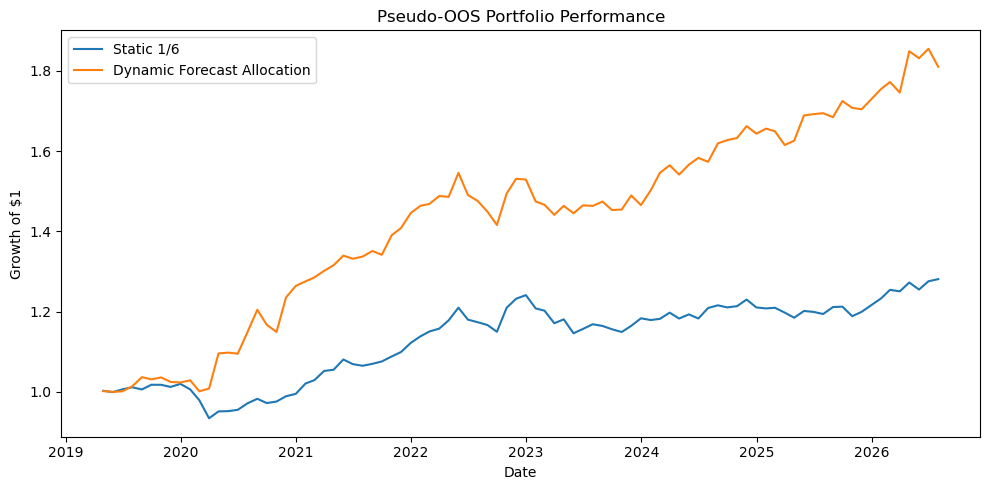

In [47]:
# ============================================================
# STEP 11B — CUMULATIVE PERFORMANCE
# ============================================================

wealth_static = (

    1
    +
    portfolio_returns["Static"]
    / 100

).cumprod()


wealth_dynamic = (

    1
    +
    portfolio_returns["Dynamic_Gross"]
    / 100

).cumprod()


plt.figure(
    figsize=(10, 5)
)

plt.plot(
    wealth_static.index,
    wealth_static,
    label="Static 1/6"
)

plt.plot(
    wealth_dynamic.index,
    wealth_dynamic,
    label="Dynamic Forecast Allocation"
)

plt.title(
    "Pseudo-OOS Portfolio Performance"
)

plt.xlabel("Date")

plt.ylabel(
    "Growth of $1"
)

plt.legend()

plt.tight_layout()

plt.show()

In [48]:
# ============================================================
# MODELING STEP 12 — TURNOVER AND TRANSACTION COSTS
# ============================================================

# ------------------------------------------------------------
# 1. Monthly portfolio turnover
# ------------------------------------------------------------

turnover = (

    dynamic_weights
    .diff()
    .abs()
    .sum(axis=1)

    / 2
)


turnover.iloc[0] = 0


print(
    "Average monthly turnover:",
    round(
        turnover.mean(),
        4
    )
)


# ------------------------------------------------------------
# 2. Transaction-cost robustness
#
# Test:
# 5 bps
# 10 bps
# 25 bps
# ------------------------------------------------------------

transaction_cost_levels = [
    5,
    10,
    25
]


net_results = []


for cost_bps in transaction_cost_levels:

    # Returns in the dataset are percentage units.
    #
    # 10 bps = 0.10 percentage points.
    transaction_cost_pct = (
        cost_bps
        / 100
    )


    trading_cost = (
        turnover
        *
        transaction_cost_pct
    )


    dynamic_net_return = (

        portfolio_returns[
            "Dynamic_Gross"
        ]

        -

        trading_cost
    )


    stats_net = portfolio_stats(
        dynamic_net_return
    )


    net_results.append({

        "Transaction_Cost_bps":
            cost_bps,

        "Average_Monthly_Turnover":
            turnover.mean(),

        "Annualized_Return":
            stats_net[
                "Annualized_Return"
            ],

        "Annualized_Volatility":
            stats_net[
                "Annualized_Volatility"
            ],

        "Sharpe":
            stats_net[
                "Sharpe"
            ],

        "Cumulative_Return":
            stats_net[
                "Cumulative_Return"
            ],

        "Max_Drawdown":
            stats_net[
                "Max_Drawdown"
            ]
    })


transaction_cost_results = pd.DataFrame(
    net_results
)


print(
    "Dynamic strategy after transaction costs:"
)

display(
    transaction_cost_results.round(4)
)

Average monthly turnover: 0.1534
Dynamic strategy after transaction costs:


,Transaction_Cost_bps,Average_Monthly_Turnover,Annualized_Return,Annualized_Volatility,Sharpe,Cumulative_Return,Max_Drawdown
0,5,0.1534,0.0843,0.0776,1.0868,0.7984,-0.0847
1,10,0.1534,0.0833,0.0776,1.0745,0.7866,-0.0853
2,25,0.1534,0.0804,0.0775,1.0376,0.7515,-0.0872


In [49]:
# ============================================================
# STEP 12B — FINAL MAIN COMPARISON
# Main transaction cost assumption = 10 bps
# ============================================================

main_cost_bps = 10

main_cost_pct = (
    main_cost_bps
    / 100
)


main_trading_cost = (
    turnover
    *
    main_cost_pct
)


portfolio_returns[
    "Dynamic_Net_10bps"
] = (

    portfolio_returns[
        "Dynamic_Gross"
    ]

    -

    main_trading_cost
)


final_performance = pd.DataFrame({

    "Static_1_6":
        portfolio_stats(
            portfolio_returns[
                "Static"
            ]
        ),

    "Dynamic_Gross":
        portfolio_stats(
            portfolio_returns[
                "Dynamic_Gross"
            ]
        ),

    "Dynamic_Net_10bps":
        portfolio_stats(
            portfolio_returns[
                "Dynamic_Net_10bps"
            ]
        )

}).T


print(
    "FINAL STATIC VS DYNAMIC COMPARISON"
)

display(
    final_performance.round(4)
)

FINAL STATIC VS DYNAMIC COMPARISON


,Annualized_Return,Annualized_Volatility,Sharpe,Cumulative_Return,Max_Drawdown
Static_1_6,0.0347,0.0520,0.6686,0.2809,-0.0840
Dynamic_Gross,0.0853,0.0776,1.0991,0.8103,-0.0841
Dynamic_Net_10bps,0.0833,0.0776,1.0745,0.7866,-0.0853


In [50]:
# ============================================================
# MODELING STEP 13 — INTEGRATED REGIME-TO-PORTFOLIO PIPELINE
# ============================================================

# ------------------------------------------------------------
# 1. Build regime series by Signal_Date
# ------------------------------------------------------------

regime_series = (
    m1["Regime_M1"]
    .copy()
)

regime_series.name = "Regime"


# ------------------------------------------------------------
# 2. Create Signal_Date / Return_Date mapping
# ------------------------------------------------------------

date_map = (
    step8_forecasts[
        ["Signal_Date", "Return_Date"]
    ]
    .drop_duplicates()
    .set_index("Signal_Date")
)


# ------------------------------------------------------------
# 3. Attach regime at time t
# ------------------------------------------------------------

regime_oos = (
    date_map
    .join(
        regime_series,
        how="left"
    )
    .reset_index()
)


print("OOS regime mapping:")

display(
    regime_oos.head()
)

OOS regime mapping:


,Signal_Date,Return_Date,Regime
0,2019-03-31,2019-04-30,Stagflation
1,2019-04-30,2019-05-31,Stagflation
2,2019-05-31,2019-06-30,Stagflation
3,2019-06-30,2019-07-31,Slowdown
4,2019-07-31,2019-08-31,Slowdown


In [51]:
# ============================================================
# STEP 13B — REGIME AND DYNAMIC WEIGHTS
# ============================================================

weights_with_regime = (
    dynamic_weights
    .reset_index()
    .merge(
        regime_oos[
            ["Return_Date", "Regime"]
        ],
        on="Return_Date",
        how="left"
    )
)


print("Dynamic weights with macro regime:")

display(
    weights_with_regime.head(10)
)

Dynamic weights with macro regime:


,Return_Date,MKT_RF_next,SMB_next,HML_next,RMW_next,CMA_next,MOM_next,Regime
0,2019-04-30,0.128051,0.019010,0.182121,0.257021,0.126808,0.286989,Stagflation
1,2019-05-31,0.211704,0.017558,0.216430,0.216254,0.110536,0.227519,Stagflation
2,2019-06-30,0.122680,0.000000,0.176510,0.287659,0.117211,0.295941,Stagflation
3,2019-07-31,0.229138,0.006992,0.059890,0.301611,0.081645,0.320725,Slowdown
4,2019-08-31,0.205136,0.041269,0.065377,0.150334,0.105821,0.432062,Slowdown
5,2019-09-30,0.180574,0.000000,0.081718,0.309268,0.097926,0.330514,Stagflation
6,2019-10-31,0.330263,0.019586,0.100604,0.115062,0.119071,0.315414,Expansion
7,2019-11-30,0.164385,0.000000,0.106584,0.240886,0.111565,0.376580,Slowdown
8,2019-12-31,0.097082,0.007138,0.164681,0.224930,0.123870,0.382298,Stagflation
9,2020-01-31,0.279938,0.004636,0.144239,0.160471,0.098171,0.312545,Overheating


In [52]:
# ------------------------------------------------------------
# Average dynamic factor weights within each regime
# ------------------------------------------------------------

regime_weight_summary = (
    weights_with_regime
    .groupby("Regime")[
        factor_order
    ]
    .mean()
)


regime_order = [
    "Expansion",
    "Overheating",
    "Slowdown",
    "Stagflation"
]


regime_weight_summary = (
    regime_weight_summary
    .reindex(regime_order)
)


print(
    "Average dynamic factor weights by regime:"
)

display(
    regime_weight_summary.round(4)
)

Average dynamic factor weights by regime:


,MKT_RF_next,SMB_next,HML_next,RMW_next,CMA_next,MOM_next
Regime,,,,,,
Expansion,0.4560,0.0059,0.0207,0.2064,0.0579,0.2530
Overheating,0.3961,0.0093,0.1260,0.1588,0.0932,0.2166
Slowdown,0.2697,0.0094,0.0245,0.2264,0.0823,0.3878
Stagflation,0.2744,0.0108,0.1259,0.2035,0.1120,0.2734


In [53]:
# ============================================================
# STEP 13C — OOS PORTFOLIO RETURNS BY REGIME
# ============================================================

portfolio_by_regime = (
    portfolio_returns
    .reset_index()
    .merge(
        regime_oos[
            ["Return_Date", "Regime"]
        ],
        on="Return_Date",
        how="left"
    )
)


regime_portfolio_summary = (
    portfolio_by_regime
    .groupby("Regime")[
        [
            "Static",
            "Dynamic_Gross",
            "Dynamic_Net_10bps"
        ]
    ]
    .agg(
        ["count", "mean", "std"]
    )
)


print(
    "OOS portfolio performance by macro regime:"
)

display(
    regime_portfolio_summary.round(4)
)

OOS portfolio performance by macro regime:


Static                 Dynamic_Gross                  \
             count    mean     std         count    mean     std   
Regime                                                             
Expansion        9  0.2869  1.5845             9  1.7770  3.3156   
Overheating     24  0.7395  1.4366            24  0.8771  2.0764   
Slowdown        19  0.1801  1.8150            19  0.7825  2.0198   
Stagflation     35  0.0574  1.3244            35  0.2789  2.1263   

            Dynamic_Net_10bps                  
                        count    mean     std  
Regime                                         
Expansion                   9  1.7519  3.2946  
Overheating                24  0.8645  2.0754  
Slowdown                   19  0.7654  2.0257  
Stagflation                35  0.2651  2.1280

In [54]:
# ============================================================
# MODELING STEP 14 — CERTAINTY-EQUIVALENT RETURN (CER)
# ============================================================

def certainty_equivalent(
    return_series,
    gamma=3
):

    # Returns are stored in percentage units
    r = (
        return_series
        .dropna()
        / 100
    )

    mean_annual = (
        r.mean()
        * 12
    )

    variance_annual = (
        r.var(ddof=1)
        * 12
    )

    cer = (
        mean_annual
        -
        0.5
        * gamma
        * variance_annual
    )

    return cer

In [55]:
# ------------------------------------------------------------
# CER comparison
# ------------------------------------------------------------

cer_results = []


for gamma in [1, 3, 5]:

    for strategy in [
        "Static",
        "Dynamic_Gross",
        "Dynamic_Net_10bps"
    ]:

        cer = certainty_equivalent(
            portfolio_returns[strategy],
            gamma=gamma
        )

        cer_results.append({

            "Risk_Aversion_Gamma":
                gamma,

            "Strategy":
                strategy,

            "CER":
                cer
        })


cer_results = pd.DataFrame(
    cer_results
)


print(
    "Certainty-equivalent return:"
)

display(
    cer_results.round(4)
)

Certainty-equivalent return:


,Risk_Aversion_Gamma,Strategy,CER
0,1,Static,0.0342
1,1,Dynamic_Gross,0.0820
2,1,Dynamic_Net_10bps,0.0802
3,3,Static,0.0315
4,3,Dynamic_Gross,0.0760
5,3,Dynamic_Net_10bps,0.0742
6,5,Static,0.0288
7,5,Dynamic_Gross,0.0700
8,5,Dynamic_Net_10bps,0.0682


In [56]:
# ============================================================
# STEP 14B — CER IMPROVEMENT OVER STATIC BENCHMARK
# ============================================================

cer_pivot = (
    cer_results
    .pivot(
        index="Risk_Aversion_Gamma",
        columns="Strategy",
        values="CER"
    )
)


cer_pivot[
    "CER_Gain_Dynamic_Net_vs_Static"
] = (

    cer_pivot[
        "Dynamic_Net_10bps"
    ]

    -

    cer_pivot[
        "Static"
    ]
)


display(
    cer_pivot.round(4)
)

Strategy,Dynamic_Gross,Dynamic_Net_10bps,Static,CER_Gain_Dynamic_Net_vs_Static
Risk_Aversion_Gamma,,,,
1,0.082,0.0802,0.0342,0.0460
3,0.076,0.0742,0.0315,0.0427
5,0.070,0.0682,0.0288,0.0394


In [57]:
# ============================================================
# MODELING STEP 15 — FINAL ECONOMIC VALUE SUMMARY
# ============================================================

final_summary = final_performance.copy()


# Add CER using gamma = 3
final_summary["CER_gamma_3"] = [

    certainty_equivalent(
        portfolio_returns["Static"],
        gamma=3
    ),

    certainty_equivalent(
        portfolio_returns["Dynamic_Gross"],
        gamma=3
    ),

    certainty_equivalent(
        portfolio_returns[
            "Dynamic_Net_10bps"
        ],
        gamma=3
    )
]


print(
    "FINAL REGIME-BASED ALLOCATION RESULTS"
)

display(
    final_summary.round(4)
)

FINAL REGIME-BASED ALLOCATION RESULTS


,Annualized_Return,Annualized_Volatility,Sharpe,Cumulative_Return,Max_Drawdown,CER_gamma_3
Static_1_6,0.0347,0.0520,0.6686,0.2809,-0.0840,0.0315
Dynamic_Gross,0.0853,0.0776,1.0991,0.8103,-0.0841,0.0760
Dynamic_Net_10bps,0.0833,0.0776,1.0745,0.7866,-0.0853,0.0742


In [58]:
# ============================================================
# MODELING STEP 16 — MACRO + REGIME OOS FORECAST ROBUSTNESS
#
# Goal:
# Compare baseline macro-only forecasts with forecasts that
# additionally include the M1 macro regime at time t.
#
# Regime_t + Macro_t  --->  Factor return at t+1
# ============================================================

import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_error


# ------------------------------------------------------------
# 1. Create regime dummies
#
# One category is omitted automatically to avoid
# perfect multicollinearity.
# ------------------------------------------------------------

regime_dummies = pd.get_dummies(
    m1["Regime_M1"],
    prefix="Regime",
    drop_first=True,
    dtype=int
)

print("Regime dummy columns:")
print(regime_dummies.columns.tolist())

display(
    regime_dummies.head()
)

Regime dummy columns:
['Regime_Overheating', 'Regime_Slowdown', 'Regime_Stagflation']


,Regime_Overheating,Regime_Slowdown,Regime_Stagflation
Date,,,
1990-03-31,1,0,0
1990-04-30,1,0,0
1990-05-31,0,0,1
1990-06-30,0,0,0
1990-07-31,1,0,0


In [59]:
# ------------------------------------------------------------
# 2. Attach regime dummies to model_data
# ------------------------------------------------------------

model_data_regime = (
    model_data
    .join(
        regime_dummies,
        how="left"
    )
)


regime_dummy_columns = (
    regime_dummies.columns.tolist()
)


predictor_columns_regime = (
    predictor_columns
    +
    regime_dummy_columns
)


print(
    "Original predictors:",
    len(predictor_columns)
)

print(
    "Regime-augmented predictors:",
    len(predictor_columns_regime)
)

print("\nRegime-augmented predictor list:")

print(
    predictor_columns_regime
)

Original predictors: 7
Regime-augmented predictors: 10

Regime-augmented predictor list:
['VIX', 'Credit_Spread', 'Term_Spread', 'Treasury_2Y_change', 'Inflation_lag1', 'Unemployment_lag1', 'IP_Growth_lag1', 'Regime_Overheating', 'Regime_Slowdown', 'Regime_Stagflation']


In [60]:
# ------------------------------------------------------------
# 3. Missing-value check
# ------------------------------------------------------------

print(
    "Missing values in regime dummies:"
)

display(
    model_data_regime[
        regime_dummy_columns
    ]
    .isna()
    .sum()
)

Missing values in regime dummies:


Regime_Overheating    0
Regime_Slowdown       0
Regime_Stagflation    0
dtype: int64

In [61]:
# ============================================================
# STEP 16B — EXPANDING WINDOW OOS:
# MACRO + REGIME
# ============================================================

step16_results_list = []
step16_forecast_records = []


for target in target_columns:

    print("\n" + "=" * 65)

    print(
        "Regime-augmented OOS target:",
        target
    )

    print("=" * 65)


    actual_values = []

    pred_ols = []
    pred_ridge = []
    pred_enet = []


    for i in range(
        initial_train,
        len(model_data_regime)
    ):

        # ----------------------------------------------------
        # Expanding training sample
        # ----------------------------------------------------

        train_expanding = (
            model_data_regime
            .iloc[:i]
            .copy()
        )

        test_one = (
            model_data_regime
            .iloc[i:i+1]
            .copy()
        )


        X_train = (
            train_expanding[
                predictor_columns_regime
            ]
        )

        y_train = (
            train_expanding[target]
        )


        X_test = (
            test_one[
                predictor_columns_regime
            ]
        )

        y_actual = (
            test_one[target]
            .iloc[0]
        )


        # ----------------------------------------------------
        # Scale predictors using training information only
        # ----------------------------------------------------

        scaler = StandardScaler()

        X_train_scaled = (
            scaler.fit_transform(
                X_train
            )
        )

        X_test_scaled = (
            scaler.transform(
                X_test
            )
        )


        # ----------------------------------------------------
        # OLS
        # ----------------------------------------------------

        ols_model = LinearRegression()

        ols_model.fit(
            X_train_scaled,
            y_train
        )

        ols_pred = (
            ols_model.predict(
                X_test_scaled
            )[0]
        )


        # ----------------------------------------------------
        # Ridge
        # Use same frozen Step 7 alpha
        # ----------------------------------------------------

        ridge_model = Ridge(
            alpha=
            frozen_params[target][
                "ridge_alpha"
            ]
        )

        ridge_model.fit(
            X_train_scaled,
            y_train
        )

        ridge_pred = (
            ridge_model.predict(
                X_test_scaled
            )[0]
        )


        # ----------------------------------------------------
        # Elastic Net
        # Use same frozen Step 7 parameters
        # ----------------------------------------------------

        elastic_model = ElasticNet(

            alpha=
            frozen_params[target][
                "elastic_alpha"
            ],

            l1_ratio=
            frozen_params[target][
                "elastic_l1_ratio"
            ],

            max_iter=10000
        )

        elastic_model.fit(
            X_train_scaled,
            y_train
        )

        elastic_pred = (
            elastic_model.predict(
                X_test_scaled
            )[0]
        )


        # ----------------------------------------------------
        # Store results
        # ----------------------------------------------------

        actual_values.append(
            y_actual
        )

        pred_ols.append(
            ols_pred
        )

        pred_ridge.append(
            ridge_pred
        )

        pred_enet.append(
            elastic_pred
        )


        step16_forecast_records.append({

            "Signal_Date":
                model_data_regime.index[i],

            "Return_Date":
                model_data_regime.index[i]
                + pd.offsets.MonthEnd(1),

            "Factor":
                target,

            "Actual":
                y_actual,

            "OLS_Regime":
                ols_pred,

            "Ridge_Regime":
                ridge_pred,

            "Elastic_Net_Regime":
                elastic_pred
        })


    # --------------------------------------------------------
    # Evaluate regime-augmented models
    # --------------------------------------------------------

    actual_values = np.array(
        actual_values
    )


    predictions = {

        "OLS_Regime":
            np.array(pred_ols),

        "Ridge_Regime":
            np.array(pred_ridge),

        "Elastic_Net_Regime":
            np.array(pred_enet)
    }


    # Historical mean benchmark from Step 8
    baseline_hist = (
        step8_forecasts
        .loc[
            step8_forecasts["Factor"]
            == target,
            "Historical_Mean"
        ]
        .values
    )


    historical_mse = (
        mean_squared_error(
            actual_values,
            baseline_hist
        )
    )


    for model_name, prediction in predictions.items():

        rmse = np.sqrt(
            mean_squared_error(
                actual_values,
                prediction
            )
        )

        mae = mean_absolute_error(
            actual_values,
            prediction
        )


        model_mse = (
            mean_squared_error(
                actual_values,
                prediction
            )
        )


        oos_r2 = (
            1
            -
            model_mse
            / historical_mse
        )


        directional_accuracy = np.mean(

            np.sign(actual_values)

            ==

            np.sign(prediction)
        )


        step16_results_list.append({

            "Factor":
                target,

            "Model":
                model_name,

            "RMSE":
                rmse,

            "MAE":
                mae,

            "OOS_R2":
                oos_r2,

            "Directional_Accuracy":
                directional_accuracy
        })


Regime-augmented OOS target: MKT_RF_next

Regime-augmented OOS target: SMB_next

Regime-augmented OOS target: HML_next

Regime-augmented OOS target: RMW_next

Regime-augmented OOS target: CMA_next

Regime-augmented OOS target: MOM_next


In [62]:
# ============================================================
# STEP 16C — FINAL REGIME-AUGMENTED FORECAST RESULTS
# ============================================================

step16_results = pd.DataFrame(
    step16_results_list
)


step16_forecasts = pd.DataFrame(
    step16_forecast_records
)


print(
    "REGIME-AUGMENTED OOS FORECAST RESULTS"
)

display(
    step16_results.round(4)
)


print(
    "\nForecast dataset shape:"
)

print(
    step16_forecasts.shape
)


print(
    "\nFirst few regime-augmented forecasts:"
)

display(
    step16_forecasts.head(12)
)

REGIME-AUGMENTED OOS FORECAST RESULTS


,Factor,Model,RMSE,MAE,OOS_R2,Directional_Accuracy
0,MKT_RF_next,OLS_Regime,5.3481,4.1336,-0.1488,0.5862
1,MKT_RF_next,Ridge_Regime,4.9899,3.9456,-0.0000,0.6207
2,MKT_RF_next,Elastic_Net_Regime,4.9898,3.9395,0.0000,0.6207
3,SMB_next,OLS_Regime,3.2769,2.4207,-0.1072,0.5057
4,SMB_next,Ridge_Regime,3.0938,2.3157,0.0130,0.5977
5,SMB_next,Elastic_Net_Regime,3.1048,2.3351,0.0060,0.5402
6,HML_next,OLS_Regime,4.1887,3.2604,0.0160,0.5172
7,HML_next,Ridge_Regime,4.2112,3.2593,0.0054,0.4943
8,HML_next,Elastic_Net_Regime,4.2227,3.2687,0.0000,0.4598
9,RMW_next,OLS_Regime,3.0788,2.3196,-0.1187,0.5517



Forecast dataset shape:
(522, 7)

First few regime-augmented forecasts:


,Signal_Date,Return_Date,Factor,Actual,OLS_Regime,Ridge_Regime,Elastic_Net_Regime
0,2019-03-31,2019-04-30,MKT_RF_next,3.97,-0.685790,0.642094,0.673649
1,2019-04-30,2019-05-31,MKT_RF_next,-6.92,0.649373,0.673828,0.683095
2,2019-05-31,2019-06-30,MKT_RF_next,6.99,-0.690532,0.626252,0.661371
3,2019-06-30,2019-07-31,MKT_RF_next,1.22,0.171538,0.643040,0.679402
4,2019-07-31,2019-08-31,MKT_RF_next,-2.55,0.229829,0.649416,0.680937
5,2019-08-31,2019-09-30,MKT_RF_next,1.42,-0.415924,0.640741,0.671785
6,2019-09-30,2019-10-31,MKT_RF_next,2.07,0.370355,0.671404,0.673898
7,2019-10-31,2019-11-30,MKT_RF_next,3.87,-0.346199,0.634071,0.677831
8,2019-11-30,2019-12-31,MKT_RF_next,2.76,-1.212454,0.651918,0.686798
9,2019-12-31,2020-01-31,MKT_RF_next,-0.09,-1.205665,0.665802,0.692605


In [63]:
# ============================================================
# STEP 16D — BASELINE VS REGIME-AUGMENTED FORECAST COMPARISON
# ============================================================

baseline_compare = (
    step8_results[
        step8_results["Model"]
        .isin(
            [
                "OLS",
                "Ridge",
                "Elastic_Net"
            ]
        )
    ]
    .copy()
)


baseline_compare[
    "Specification"
] = "Macro_Only"


regime_compare = (
    step16_results
    .copy()
)


regime_compare[
    "Specification"
] = "Macro_Plus_Regime"


# Remove "_Regime" for easier model comparison
regime_compare["Model"] = (
    regime_compare["Model"]
    .str.replace(
        "_Regime",
        "",
        regex=False
    )
)


forecast_comparison = pd.concat(
    [
        baseline_compare,
        regime_compare
    ],
    ignore_index=True
)


forecast_comparison = (
    forecast_comparison
    .sort_values(
        [
            "Factor",
            "Model",
            "Specification"
        ]
    )
)


display(
    forecast_comparison[
        [
            "Factor",
            "Model",
            "Specification",
            "RMSE",
            "MAE",
            "OOS_R2",
            "Directional_Accuracy"
        ]
    ].round(4)
)

,Factor,Model,Specification,RMSE,MAE,OOS_R2,Directional_Accuracy
14,CMA_next,Elastic_Net,Macro_Only,2.7709,2.2358,-0.0000,0.4483
32,CMA_next,Elastic_Net,Macro_Plus_Regime,2.7709,2.2358,-0.0000,0.4483
12,CMA_next,OLS,Macro_Only,2.7511,2.2165,0.0143,0.5172
30,CMA_next,OLS,Macro_Plus_Regime,2.7187,2.2050,0.0373,0.4483
13,CMA_next,Ridge,Macro_Only,2.7691,2.2344,0.0013,0.4483
31,CMA_next,Ridge,Macro_Plus_Regime,2.7670,2.2338,0.0028,0.4483
8,HML_next,Elastic_Net,Macro_Only,4.2227,3.2687,0.0000,0.4598
26,HML_next,Elastic_Net,Macro_Plus_Regime,4.2227,3.2687,0.0000,0.4598
6,HML_next,OLS,Macro_Only,4.1655,3.2277,0.0269,0.5517
24,HML_next,OLS,Macro_Plus_Regime,4.1887,3.2604,0.0160,0.5172


In [64]:
# ============================================================
# STEP 16E — OOS R2 COMPARISON TABLE
# ============================================================

r2_comparison = (
    forecast_comparison
    .pivot_table(
        index=[
            "Factor",
            "Model"
        ],
        columns="Specification",
        values="OOS_R2"
    )
)


r2_comparison[
    "Regime_Improvement"
] = (

    r2_comparison[
        "Macro_Plus_Regime"
    ]

    -

    r2_comparison[
        "Macro_Only"
    ]
)


print(
    "Change in OOS R² after adding regime information:"
)

display(
    r2_comparison.round(4)
)

Change in OOS R² after adding regime information:


Specification            Macro_Only  Macro_Plus_Regime  Regime_Improvement
Factor      Model                                                         
CMA_next    Elastic_Net     -0.0000            -0.0000              0.0000
            OLS              0.0143             0.0373              0.0231
            Ridge            0.0013             0.0028              0.0015
HML_next    Elastic_Net      0.0000             0.0000              0.0000
            OLS              0.0269             0.0160             -0.0109
            Ridge            0.0043             0.0054              0.0011
MKT_RF_next Elastic_Net      0.0000             0.0000              0.0000
            OLS             -0.0245            -0.1488             -0.1242
            Ridge           -0.0004            -0.0000              0.0004
MOM_next    Elastic_Net      0.0018             0.0018              0.0000
            OLS             -0.0447            -0.1263             -0.0816
            Ridge            0.0023             0.0025              0.0002
RMW_next    Elastic_Net      0.0000             0.0000              0.0000
            OLS             -0.0751            -0.1187             -0.0436
            Ridge           -0.0048            -0.0026              0.0022
SMB_next    Elastic_Net      0.0084             0.0060             -0.0024
            OLS             -0.0080            -0.1072             -0.0992
            Ridge            0.0216             0.0130             -0.0086